# Monash Solar Farm — Data Loading

**Purpose of this notebook: load every data file in the project into a named
variable, and nothing else.** No analysis, no modelling. By the end you have all
the raw material in memory and know what each variable holds.

## What the project is

Monash's Clayton campus has a microgrid: six buildings that consume electricity,
six rooftop solar installations that generate it, and batteries that store it.
The project has two parts.

| | Part 1 — Predict | Part 2 — Optimise |
|---|---|---|
| **Task** | Forecast electricity demand for 6 buildings and solar production from 6 arrays | Schedule battery charge/discharge and lecture activities |
| **Resolution** | Every 15 minutes | Every 15 minutes |
| **Target period** | October 2020 (Phase 1) or November 2020 (Phase 2) | Same months |
| **Scored by** | Mean MASE across all 12 series | Cost: peak-demand tariff + activity values |

Part 2 consumes the forecasts from Part 1 — you decide when to charge the battery
(when solar is plentiful or prices are low) and when to discharge it (when demand
peaks or prices are high).

## The files

| File | What it is |
|---|---|
| `phase_1_data.tsf` | The 12 series, history up to **30 Sep 2020**. Training data for predicting October. |
| `phase_2_data.tsf` | The same 12 series, up to **31 Oct 2020**. Training data for predicting November. |
| `nov_data.tsf` | The same 12 series, up to **30 Nov 2020**. Contains the **answers** for both October and November. |
| `ERA5_Weather_Data_Monash.csv` | Hourly weather near campus, 2010–2021. Supplied by the unit because the Bureau of Meteorology only lets you download daily data. |
| `phase_1_instances/`, `phase_2_instances_utc.zip` | Part 2 optimisation problems — buildings, batteries and activities to schedule. |

The three `.tsf` files are **nested snapshots of the same 12 series**, not different
data. `nov_data.tsf` contains everything the other two contain, plus more months.

## 1. Imports and file paths

In [1]:
import zipfile
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 50)

# This notebook lives in the project root; the data sits in MonashSolarFarm/.
DATA = Path.cwd() / "MonashSolarFarm"
if not DATA.exists():
    DATA = Path.cwd()          # in case the notebook is moved next to the data
assert (DATA / "nov_data.tsf").exists(), f"could not find the data under {DATA}"

# Timestamps inside the data files are UTC. Melbourne is UTC+10 in winter and
# UTC+11 during daylight saving, which is in force across October and November -
# exactly the period we forecast. Converting to this timezone makes pandas handle
# the changeover for us.
LOCAL_TZ = "Australia/Melbourne"

print("data folder:", DATA)
for f in sorted(DATA.iterdir()):
    if f.suffix in {".tsf", ".csv", ".zip"} or f.is_dir():
        size = f.stat().st_size / 1e6
        print(f"  {f.name:36s} {size:8.2f} MB")

data folder: /Users/pahansenevirathne/Documents/data challenges 4/MonashSolarFarm
  ERA5_Weather_Data_Monash.csv            10.28 MB
  ERA5_Weather_Data_Monash.zip             2.26 MB
  IDCJAC0010_86338_1800.zip                0.02 MB
  Predict_eval_and_data_R_scripts          0.00 MB
  final_test_data.zip                      0.52 MB
  nov_data.tsf                             3.09 MB
  phase_1_data.tsf                         2.82 MB
  phase_1_data.zip                         0.46 MB
  phase_1_instances                        0.00 MB
  phase_1_instances.zip                    0.02 MB
  phase_2_data.tsf                         2.95 MB
  phase_2_data.zip                         0.49 MB
  phase_2_instances_utc.zip                0.02 MB


## 2. The `.tsf` files (building demand and solar production)

`.tsf` is a plain-text time-series format. It looks like this:

```
# comment lines
@relation energy_demand
@frequency 15_minutes
@missing true
@equallength false
@data
Building0:2016-07-03 21-30-00:283.8,283.8,283.8,606,606,?,306,...
Solar0:2020-04-25 14-00-00:0,0,0,0.12,...
```

After `@data`, each line is one complete time series in the form
**`Name : start_timestamp : comma-separated values`**.

Three consequences worth understanding before writing the parser:

- `@equallength false` — every series has a **different length**.
- Each series carries its **own start timestamp**, so they do not begin on the
  same date. There is no date column; you reconstruct dates by counting 15-minute
  steps forward from that start.
- `@missing true` — a `?` means a missing reading, which becomes `NaN`.

In [2]:
def load_tsf(path):
    """
    Read a .tsf file.

    Returns a dict of {series_name: pandas Series}, each with a proper
    15-minute UTC DatetimeIndex reconstructed from its own start timestamp.
    """
    series = {}
    with open(path) as fh:
        for line in fh:
            line = line.rstrip("\n")

            # Skip comments, blank lines, and the @tag header lines.
            if not line or line.startswith("#") or line.startswith("@"):
                continue

            # Everything after @data has the shape  name:timestamp:v1,v2,v3,...
            name, timestamp, values = line.split(":", 2)

            # "2016-07-03 21-30-00"  ->  a real timestamp, tagged as UTC
            start = pd.Timestamp(datetime.strptime(timestamp, "%Y-%m-%d %H-%M-%S"), tz="UTC")

            # "?" marks a missing reading
            numbers = [np.nan if v == "?" else float(v) for v in values.split(",")]

            # Build the dates by stepping forward 15 minutes at a time
            index = pd.date_range(start=start, periods=len(numbers), freq="15min", tz="UTC")

            series[name] = pd.Series(numbers, index=index, name=name)
    return series


# Load all three snapshots.
tsf_files = {
    "phase1": DATA / "phase_1_data.tsf",   # history to 30 Sep 2020
    "phase2": DATA / "phase_2_data.tsf",   # history to 31 Oct 2020
    "nov":    DATA / "nov_data.tsf",       # history to 30 Nov 2020 (the answers)
}
tsf = {label: load_tsf(path) for label, path in tsf_files.items()}

for label, series in tsf.items():
    ends = max(s.index[-1] for s in series.values())
    print(f"{label:7s} {len(series)} series, ending {ends.tz_convert(LOCAL_TZ):%Y-%m-%d %H:%M} local")

phase1  12 series, ending 2020-10-01 09:45 local
phase2  12 series, ending 2020-11-01 10:45 local
nov     12 series, ending 2020-12-01 10:45 local


In [3]:
# Turn the fullest snapshot into one wide table: rows = 15-minute stamps,
# columns = the 12 series. pandas aligns them on the union of their timestamps,
# filling NaN where a series had not started yet.
df = pd.DataFrame(tsf["nov"]).asfreq("15min").tz_convert(LOCAL_TZ)

# Two convenient groupings. Note there is NO Building2 - the numbering skips it,
# in the data and in the Part 2 optimisation instances alike.
BUILDINGS = [c for c in df.columns if c.startswith("Building")]
SOLAR = [c for c in df.columns if c.startswith("Solar")]

print("buildings:", BUILDINGS)
print("solar    :", SOLAR)
print(f"\nshape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"span : {df.index[0]:%Y-%m-%d %H:%M} -> {df.index[-1]:%Y-%m-%d %H:%M} (local time)")
df.head()

buildings: ['Building0', 'Building1', 'Building3', 'Building4', 'Building5', 'Building6']
solar    : ['Solar0', 'Solar1', 'Solar2', 'Solar3', 'Solar4', 'Solar5']

shape: 166,639 rows x 12 columns
span : 2016-03-01 15:15 -> 2020-12-01 10:45 (local time)


,Building0,Building1,Building3,Building4,Building5,Building6,Solar0,Solar1,Solar2,Solar3,Solar4,Solar5
2016-03-01 15:15:00+11:00,NaN,NaN,1321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 15:30:00+11:00,NaN,NaN,1321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 15:45:00+11:00,NaN,NaN,1321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 16:00:00+11:00,NaN,NaN,1321.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 16:15:00+11:00,NaN,NaN,1293.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# What each series actually contains. Read this before doing anything else -
# the series are far less uniform than "12 series at 15 minutes" suggests.
summary = pd.DataFrame({
    "start (local)": [tsf["nov"][c].index[0].tz_convert(LOCAL_TZ).strftime("%Y-%m-%d") for c in df.columns],
    "n readings":    [len(tsf["nov"][c]) for c in df.columns],
    "missing %":     [round(100 * tsf["nov"][c].isna().mean(), 1) for c in df.columns],
    "min":           [round(tsf["nov"][c].min(), 2) for c in df.columns],
    "max":           [round(tsf["nov"][c].max(), 2) for c in df.columns],
    "mean":          [round(tsf["nov"][c].mean(), 2) for c in df.columns],
}, index=df.columns)
summary.index.name = "series"
summary

,start (local),n readings,missing %,min,max,mean
series,,,,,,
Building0,2016-07-04,154666,30.7,0.1,6781.50,224.57
Building1,2019-01-10,66339,0.1,1.5,83.50,11.22
Building3,2016-03-01,166639,0.3,85.0,8556.00,512.83
Building4,2019-07-03,49613,40.3,1.0,5.00,1.32
Building5,2019-07-26,47428,73.3,1.0,62.00,24.64
Building6,2019-07-25,47513,4.8,0.2,102.20,30.67
Solar0,2020-04-26,21064,0.0,0.0,53.27,6.25
Solar1,2019-01-01,67244,0.0,0.0,13.04,2.02
Solar2,2019-06-06,52264,0.0,0.0,13.96,1.99


A few things to notice in that table, because they shape everything later:

- **History lengths differ wildly.** Building3 starts in March 2016; Solar0 starts
  in April 2020, giving it only about five months of history before the forecast
  window.
- **Scale differs by three orders of magnitude.** Building4 never leaves the
  1–5 kW range while Building3 reaches 8,556 kW. Never plot them on shared axes.
- **Missingness is severe for two series** — Building4 around 40% and Building5
  around 73%.
- **Nothing is ever negative.** Buildings cannot consume negative power and panels
  cannot generate it, so your forecasts should not go negative either.

### Marking the forecast windows — and a daylight-saving trap

`df` now holds October and November 2020, the periods you are supposed to be
predicting. Splitting them off explicitly makes it hard to train on the answers
by accident.

**Define the boundaries in UTC, not local time.** The forecast horizons are fixed
step counts — Phase 1 is 2,976 fifteen-minute steps (31 × 96), Phase 2 is 2,880
(30 × 96) — counted forward from where each training file ends, and the files are
stamped in UTC.

Melbourne moved to daylight saving on **4 October 2020**, so the *local* calendar
month of October contains only 23 hours on that day and therefore **2,972** steps,
not 2,976. Slicing by local calendar month silently gives you four rows too few
and a submission that fails validation. Slicing on UTC instants gives the right
count. Because the index is timezone-aware, comparing it against UTC timestamps
works directly — pandas compares absolute instants regardless of display timezone.

In [5]:
# UTC boundaries - see the note above on why these must not be local-time months.
OCT = (pd.Timestamp("2020-10-01", tz="UTC"), pd.Timestamp("2020-11-01", tz="UTC"))
NOV = (pd.Timestamp("2020-11-01", tz="UTC"), pd.Timestamp("2020-12-01", tz="UTC"))

train = df.loc[df.index < OCT[0]]                               # everything to 30 Sep
test_oct = df.loc[(df.index >= OCT[0]) & (df.index < OCT[1])]    # Phase 1 answers
test_nov = df.loc[(df.index >= NOV[0]) & (df.index < NOV[1])]    # Phase 2 answers

for label, part in [("train", train), ("test_oct", test_oct), ("test_nov", test_nov)]:
    last_utc = part.index[-1].tz_convert("UTC")
    print(f"{label:8s} {len(part):>7,} rows   ends {part.index[-1]:%Y-%m-%d %H:%M} local "
          f"= {last_utc:%Y-%m-%d %H:%M} UTC")

# train ends 2020-10-01 09:45 in Melbourne time, which is still 2020-09-30 23:45
# UTC - the last step before the Phase 1 window opens. No October data leaks in.
print(f"\ntest_oct expected 2,976 = 31 x 96   -> {'OK' if len(test_oct) == 2976 else 'MISMATCH'}")
print(f"test_nov expected 2,880 = 30 x 96   -> {'OK' if len(test_nov) == 2880 else 'MISMATCH'}")

# The trap, demonstrated: the same month sliced by local calendar date.
local_oct = df.loc["2020-10"]
print(f"\nSliced as a local calendar month instead: {len(local_oct):,} rows "
      f"({2976 - len(local_oct)} short, because 4 Oct 2020 lost an hour to DST)")

train    160,783 rows   ends 2020-10-01 09:45 local = 2020-09-30 23:45 UTC
test_oct   2,976 rows   ends 2020-11-01 10:45 local = 2020-10-31 23:45 UTC
test_nov   2,880 rows   ends 2020-12-01 10:45 local = 2020-11-30 23:45 UTC

test_oct expected 2,976 = 31 x 96   -> OK
test_nov expected 2,880 = 30 x 96   -> OK

Sliced as a local calendar month instead: 2,972 rows (4 short, because 4 Oct 2020 lost an hour to DST)


## 3. ERA5 weather

Hourly reanalysis weather for a single point (-37.91, 145.13) beside the Clayton
campus, covering 2010 to mid-2021 — so both forecast months are covered.

"Reanalysis" means this is the weather that **actually happened**, reconstructed
after the fact, not a forecast made in advance. It is a legitimate input for this
project, but be aware it hands your model perfect knowledge of future weather,
which a real operational forecaster would never have.

The most useful column is `surface_solar_radiation` — it is close to a direct
physical driver of solar panel output.

In [6]:
era5 = pd.read_csv(DATA / "ERA5_Weather_Data_Monash.csv")
print("columns as they appear in the file:")
for c in era5.columns:
    print("   ", c)

# The timestamp column is UTC; convert to Melbourne local time so it lines up
# with df above.
era5["datetime (UTC)"] = pd.to_datetime(era5["datetime (UTC)"], utc=True)
era5 = era5.set_index("datetime (UTC)").sort_index().tz_convert(LOCAL_TZ)
era5.index.name = "timestamp"

# Several columns are the same value on every row (the location, the model name).
# They carry no information, so drop them.
constant_cols = [c for c in era5.columns if era5[c].nunique(dropna=False) <= 1]
print("\ndropping constant columns:", constant_cols)
era5 = era5.drop(columns=constant_cols)

# Shorten "temperature (degC)" to "temperature" etc.
era5.columns = [c.split(" (")[0] for c in era5.columns]

print(f"\nshape: {era5.shape[0]:,} rows x {era5.shape[1]} columns")
print(f"span : {era5.index[0]:%Y-%m-%d} -> {era5.index[-1]:%Y-%m-%d}")
print("missing values:", int(era5.isna().sum().sum()))
era5.head()

columns as they appear in the file:
    datetime (UTC)
    coordinates (lat,lon)
    model (name)
    model elevation (surface)
    utc_offset (hrs)
    temperature (degC)
    dewpoint_temperature (degC)
    wind_speed (m/s)
    mean_sea_level_pressure (Pa)
    relative_humidity ((0-1))
    surface_solar_radiation (W/m^2)
    surface_thermal_radiation (W/m^2)
    total_cloud_cover (0-1)

dropping constant columns: ['coordinates (lat,lon)', 'model (name)', 'model elevation (surface)', 'utc_offset (hrs)']

shape: 100,057 rows x 8 columns
span : 2010-01-01 -> 2021-06-01
missing values: 0


,temperature,dewpoint_temperature,wind_speed,mean_sea_level_pressure,relative_humidity,surface_solar_radiation,surface_thermal_radiation,total_cloud_cover
timestamp,,,,,,,,
2010-01-01 11:00:00+11:00,18.26,16.39,2.60,101046.38,0.89,287.01,408.35,1.0
2010-01-01 12:00:00+11:00,18.67,16.29,2.91,101037.96,0.86,360.79,411.02,1.0
2010-01-01 13:00:00+11:00,18.16,15.89,3.26,101017.26,0.87,291.54,410.67,1.0
2010-01-01 14:00:00+11:00,18.46,15.33,3.17,101022.56,0.82,357.11,410.95,1.0
2010-01-01 15:00:00+11:00,18.53,15.11,2.95,100940.03,0.80,459.91,410.00,0.9


In [7]:
era5.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
temperature,100057.0,14.80,5.58,0.86,10.83,13.92,18.00,40.36
dewpoint_temperature,100057.0,9.50,3.60,-2.32,6.86,9.09,11.86,22.94
wind_speed,100057.0,3.91,2.05,0.02,2.30,3.67,5.28,13.23
mean_sea_level_pressure,100057.0,101613.13,925.85,96725.92,101169.94,101703.71,102201.65,103397.53
relative_humidity,100057.0,0.73,0.16,0.12,0.62,0.76,0.85,1.09
surface_solar_radiation,100057.0,182.92,265.32,0.00,0.00,7.22,316.23,1112.14
surface_thermal_radiation,100057.0,324.62,32.93,232.15,300.51,322.90,347.15,458.76
total_cloud_cover,100057.0,0.59,0.36,0.00,0.27,0.65,0.94,1.00


### Relationships between the raw weather variables

Before using these as model inputs it is worth seeing how they relate to each
other. Three views, each answering something the others cannot:

- **A clustermap**, which reorders the variables so that mutually-correlated ones
  sit together. This is the one that answers "which of these are saying the same
  thing?" — the practical question for feature selection.
- **A pair grid**, showing each joint distribution as a density rather than a
  single coefficient. A correlation of 0.0 can hide a strong curved relationship,
  and only the scatter reveals it.
- **Focused fits** against `surface_solar_radiation`, the variable that actually
  drives solar output.

All three use **daylight hours only**. At night radiation is pinned at zero, which
would put a large spike at the origin of every panel and distort every correlation
involving it.

weather variables: ['temperature', 'dewpoint_temperature', 'wind_speed', 'mean_sea_level_pressure', 'relative_humidity', 'surface_solar_radiation', 'surface_thermal_radiation', 'total_cloud_cover']
47,755 daylight hours; plotting a 4,000-row sample


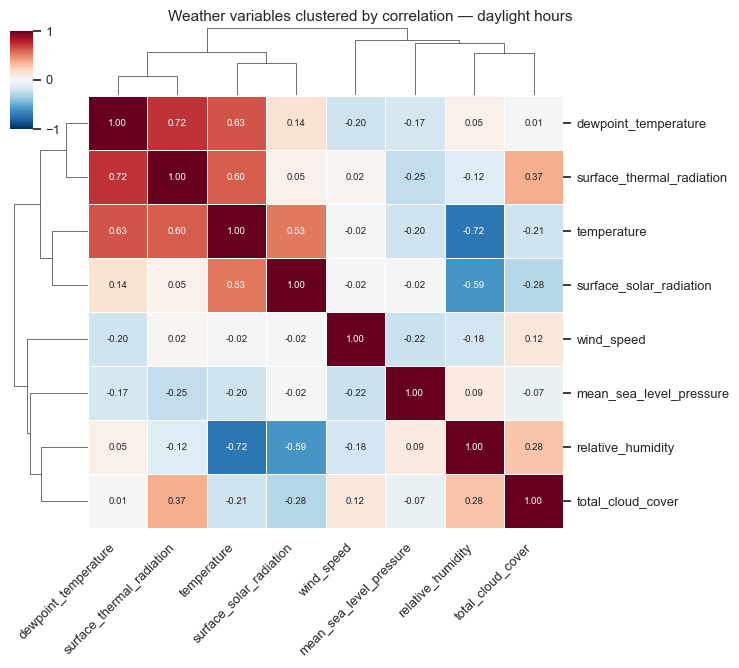

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# The 8 weather variables left after the constant columns were dropped above.
WEATHER = list(era5.columns)
print("weather variables:", WEATHER)

sns.set_theme(style="white", font_scale=0.85)

# Daylight only, and a sample for plotting - 100k points would be an unreadable
# smear and slow to render.
day_weather = era5.loc[era5["surface_solar_radiation"] > 20, WEATHER]
sample = day_weather.sample(n=min(4000, len(day_weather)), random_state=0)
print(f"{len(day_weather):,} daylight hours; plotting a {len(sample):,}-row sample")

corr = day_weather.corr()
g = sns.clustermap(
    corr, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.5, linecolor="white",
    figsize=(7.5, 7), cbar_pos=(0.02, 0.83, 0.03, 0.14),
    dendrogram_ratio=0.14)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right")
g.figure.suptitle("Weather variables clustered by correlation — daylight hours",
                  x=0.5, y=1.0, fontsize=11)
plt.show()

The dendrogram is the useful part. Branches that join close to the left are near-
duplicates, and keeping both gives a linear model unstable coefficients while
giving a tree nothing extra. The pairs to look for are **temperature with
dewpoint** and **radiation with cloud cover** — physically linked, and flagged in
the literature review as the classic redundancy in this feature set.

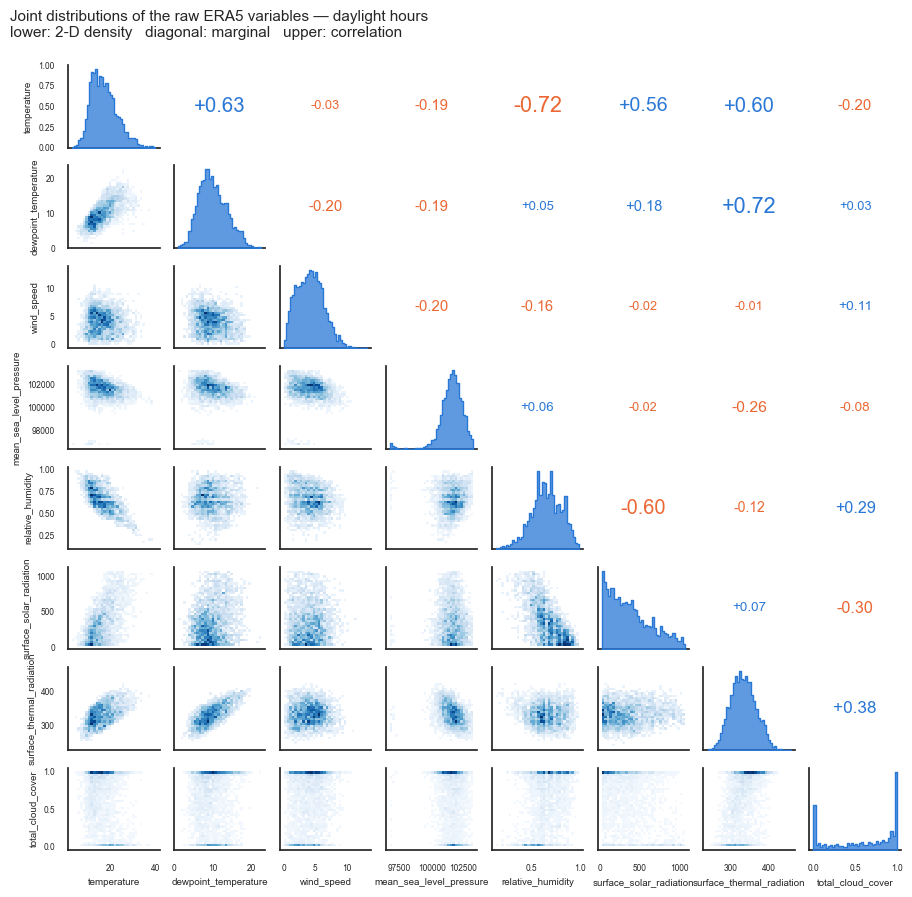

In [9]:
def corr_label(x, y, **kws):
    """Annotate the upper triangle with the correlation coefficient."""
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    ax.annotate(f"{r:+.2f}", xy=(0.5, 0.5), xycoords="axes fraction",
                ha="center", va="center",
                fontsize=9 + abs(r) * 9,
                color="#2a78d6" if r > 0 else "#eb6834")
    ax.set_axis_off()


grid = sns.PairGrid(sample, diag_sharey=False, height=1.15, corner=False)
grid.map_lower(sns.histplot, bins=32, cmap="Blues", cbar=False, pthresh=0.02)
grid.map_diag(sns.histplot, color="#2a78d6", bins=40, element="step", fill=True)
grid.map_upper(corr_label)
for ax in grid.axes.flatten():
    ax.tick_params(labelsize=6)
    ax.set_xlabel(ax.get_xlabel(), fontsize=7)
    ax.set_ylabel(ax.get_ylabel(), fontsize=7)
grid.figure.suptitle(
    "Joint distributions of the raw ERA5 variables — daylight hours\n"
    "lower: 2-D density   diagonal: marginal   upper: correlation",
    x=0.01, ha="left", fontsize=11)
grid.figure.subplots_adjust(top=0.92)
plt.show()

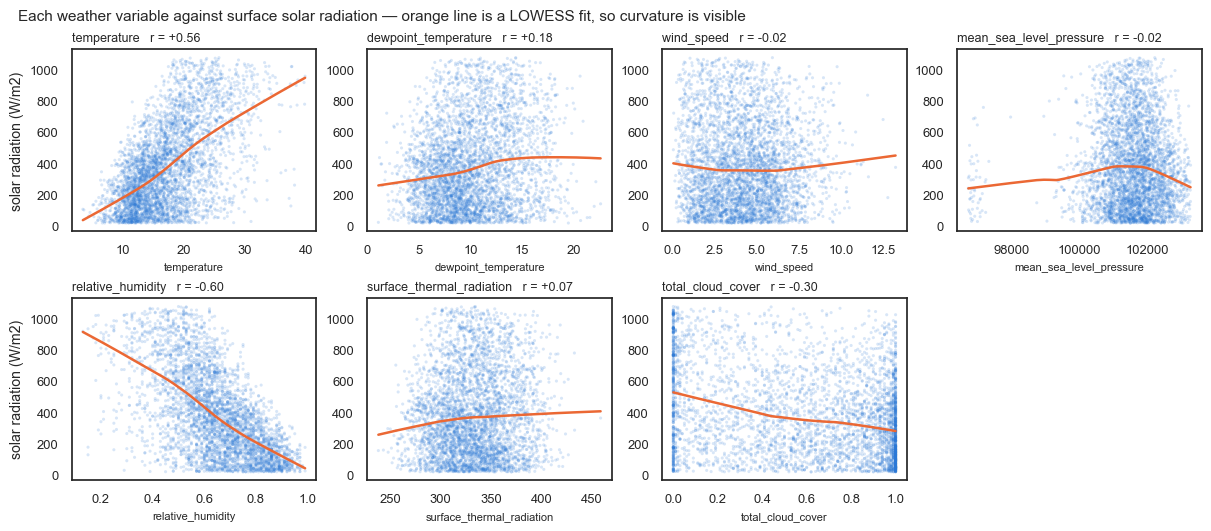

In [10]:
# What actually relates to the driver of solar output?
others = [c for c in WEATHER if c != "surface_solar_radiation"]
fig, axes = plt.subplots(2, 4, figsize=(12, 5.2), constrained_layout=True)

for ax, col in zip(axes.ravel(), others):
    sns.regplot(data=sample, x=col, y="surface_solar_radiation", ax=ax,
                scatter_kws={"s": 5, "alpha": 0.18, "color": "#2a78d6",
                             "edgecolors": "none"},
                line_kws={"color": "#eb6834", "lw": 1.8},
                lowess=True)
    r = sample[col].corr(sample["surface_solar_radiation"])
    ax.set_title(f"{col}   r = {r:+.2f}", loc="left", fontsize=9)
    ax.set_ylabel("solar radiation (W/m2)" if ax in axes[:, 0] else "")
    ax.set_xlabel(col, fontsize=8)

axes.ravel()[-1].set_visible(len(others) == 8)
fig.suptitle("Each weather variable against surface solar radiation — "
             "orange line is a LOWESS fit, so curvature is visible",
             x=0.01, ha="left", fontsize=11)
plt.show()

sns.set_theme(style="white")   # leave the theme in a known state for later cells
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.7, "axes.axisbelow": True,
    "legend.frameon": False,
})

**What to take from these.**

The LOWESS fits are the point of the last panel: a near-zero correlation
coefficient does not mean "no relationship", it means "no *linear* relationship".
Where the orange line curves, a linear model cannot use that variable but a tree
or a network can — which is part of why Ridge scored 0.99 MASE in section 12 while
the forest reached 0.72.

For feature selection, the clustermap and the permutation importance in section
11a agree: `dewpoint_temperature` sits in the same branch as `temperature`, and
`wind_speed` and `mean_sea_level_pressure` are near-independent of radiation and
scored at or below zero importance. Those are the drop candidates.

## 4. Part 2 optimisation instances

These describe the scheduling problems. Each file is a small text spec where the
first letter of a line says what the line is:

| Line | Meaning |
|---|---|
| `ppoi 6 6 2 50 20` | Header: 6 buildings, 6 solar arrays, 2 batteries, 50 recurring activities, 20 once-off activities |
| `b 0 1 0` | Building 0 has 1 small room and 0 large rooms |
| `s 2 3` | Solar array 2 is attached to Building 3 |
| `c 0 1 150 75 0.85` | Battery 0 sits at Building 1: 150 kWh capacity, 75 kW max power, 85% round-trip efficiency |
| `r 0 3 S 170 5 0` | Recurring activity 0 needs 3 small rooms, draws 170 kW, lasts 5 steps (75 min), has 0 prerequisites |
| `a 0 1 L 289 9 38 24 1 14` | Once-off activity 0 needs 1 large room, 289 kW, 9 steps, worth \$38, \$24 penalty if scheduled out of hours, 1 prerequisite (activity 14) |

Recurring activities are lectures: they **must** be scheduled, on weekdays between
09:00 and 17:00. Once-off activities are optional — you earn their value by
scheduling them, and lose part of it if you place them outside office hours.

In [11]:
def load_instance(text):
    """Parse one optimisation instance file into a dict of DataFrames."""
    head, buildings, solar, batteries, recurring, once_off = None, [], [], [], [], []

    for line in text.splitlines():
        parts = line.split()
        if not parts:
            continue
        kind, rest = parts[0], parts[1:]

        if kind == "ppoi":
            head = dict(zip(["n_buildings", "n_solar", "n_batteries",
                             "n_recurring", "n_once_off"], map(int, rest)))
        elif kind == "b":
            buildings.append(dict(zip(["building", "small_rooms", "large_rooms"], map(int, rest))))
        elif kind == "s":
            solar.append(dict(zip(["solar", "building"], map(int, rest))))
        elif kind == "c":
            batteries.append({"battery": int(rest[0]), "building": int(rest[1]),
                              "capacity_kwh": float(rest[2]), "max_power_kw": float(rest[3]),
                              "efficiency": float(rest[4])})
        elif kind in ("r", "a"):
            # Both activity types start the same way; once-off adds value + penalty.
            act = {"activity": int(rest[0]), "n_rooms": int(rest[1]), "room_size": rest[2],
                   "load_kw": float(rest[3]), "duration_steps": int(rest[4])}
            tail = rest[5:]
            if kind == "a":
                act["value"], act["penalty"] = float(tail[0]), float(tail[1])
                tail = tail[2:]
            # Remaining fields: a count of prerequisites, then that many activity ids.
            act["precedences"] = [int(x) for x in tail[1:1 + int(tail[0])]]
            (recurring if kind == "r" else once_off).append(act)

    return {"header": head,
            "buildings": pd.DataFrame(buildings),
            "solar": pd.DataFrame(solar),
            "batteries": pd.DataFrame(batteries),
            "recurring": pd.DataFrame(recurring),
            "once_off": pd.DataFrame(once_off)}


instances = {}

# Phase 1 instances are already extracted into a folder.
for path in sorted((DATA / "phase_1_instances").glob("*.txt")):
    instances[path.stem] = load_instance(path.read_text())

# Phase 2 instances are still zipped - read them without extracting.
with zipfile.ZipFile(DATA / "phase_2_instances_utc.zip") as zf:
    for name in sorted(n for n in zf.namelist() if n.endswith(".txt")):
        instances[Path(name).stem] = load_instance(zf.read(name).decode())

print(f"loaded {len(instances)} instances\n")
pd.DataFrame({k: v["header"] for k, v in instances.items()}).T

loaded 20 instances



,n_buildings,n_solar,n_batteries,n_recurring,n_once_off
phase1_instance_large_0,6,6,2,200,100
phase1_instance_large_1,6,6,2,200,100
phase1_instance_large_2,6,6,2,200,100
phase1_instance_large_3,6,6,2,200,100
phase1_instance_large_4,6,6,2,200,100
phase1_instance_small_0,6,6,2,50,20
phase1_instance_small_1,6,6,2,50,20
phase1_instance_small_2,6,6,2,50,20
phase1_instance_small_3,6,6,2,50,20
phase1_instance_small_4,6,6,2,50,20


In [12]:
# Look at one instance to see the structure.
inst = instances["phase1_instance_small_0"]

print("BATTERIES")
print(inst["batteries"].to_string(index=False))
print("\nSOLAR -> BUILDING mapping")
print(inst["solar"].to_string(index=False))
print("\nRECURRING activities (first 5 of "
      f"{len(inst['recurring'])}) - these MUST all be scheduled")
print(inst["recurring"].head().to_string(index=False))
print("\nONCE-OFF activities (first 5 of "
      f"{len(inst['once_off'])}) - optional, worth money")
print(inst["once_off"].head().to_string(index=False))

BATTERIES
 battery  building  capacity_kwh  max_power_kw  efficiency
       0         1         150.0          75.0        0.85
       1         3         420.0          60.0        0.60

SOLAR -> BUILDING mapping
 solar  building
     0         0
     1         1
     2         3
     3         4
     4         5
     5         6

RECURRING activities (first 5 of 50) - these MUST all be scheduled
 activity  n_rooms room_size  load_kw  duration_steps                                       precedences
        0        3         S    253.0               7                    [2, 9, 22, 24, 27, 32, 43, 45]
        1        2         S    364.0               6                                                []
        2        2         S    242.0               4                                  [24, 35, 42, 45]
        3        1         S    261.0               5 [0, 2, 4, 19, 21, 29, 30, 35, 42, 43, 44, 47, 48]
        4        2         S    378.0               4                          

## 5. Sanity check

One plot, purely to confirm the data loaded correctly and the timezone is right.
If solar production peaks around the middle of the day, the timestamps are being
interpreted properly. If it peaked at 2am, the timezone handling would be wrong.

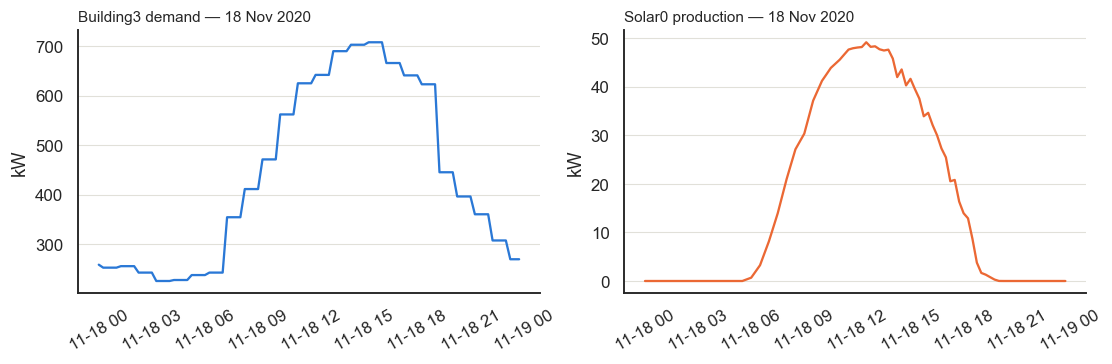

Average solar output peaks at 12:00 local time (looks correct)


In [13]:
import matplotlib.pyplot as plt

day = df.loc["2020-11-18"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), constrained_layout=True)

axes[0].plot(day.index, day["Building3"], color="#2a78d6")
axes[0].set_title("Building3 demand — 18 Nov 2020", loc="left")
axes[0].set_ylabel("kW")

axes[1].plot(day.index, day["Solar0"], color="#eb6834")
axes[1].set_title("Solar0 production — 18 Nov 2020", loc="left")
axes[1].set_ylabel("kW")

for ax in axes:
    ax.grid(True, axis="y", color="#e1e0d9", linewidth=0.7)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(axis="x", rotation=30)
plt.show()

peak_hour = df["Solar0"].groupby(df.index.hour).mean().idxmax()
print(f"Average solar output peaks at {peak_hour}:00 local time "
      f"({'looks correct' if 10 <= peak_hour <= 15 else 'SUSPICIOUS - check the timezone'})")

## 6. What you now have

| Variable | Contents |
|---|---|
| `df` | Wide table, 15-minute local-time index, all 12 series. The main object. |
| `train` / `test_oct` / `test_nov` | `df` split at the forecast boundaries |
| `tsf` | `{"phase1", "phase2", "nov"}` → dict of individual Series, if you need a single series at its own natural length |
| `BUILDINGS` / `SOLAR` | Column-name lists for the two groups |
| `era5` | Hourly weather, local-time index, constant columns removed |
| `instances` | 20 optimisation problems (10 phase 1, 10 phase 2), each a dict of DataFrames |
| `load_tsf` / `load_instance` | The two parsers, reusable in later notebooks |

**Where to go next.** The natural next step is exploring one thing at a time:
what a typical day and week look like, how demand differs between weekday and
weekend, how solar output tracks `surface_solar_radiation`, and how much of each
series is missing. Do that in a separate notebook and keep this one as the clean
loading step you can re-run any time.

A fuller exploratory pass already exists at
`MonashSolarFarm/01_eda_usage_weather.ipynb` if you want to compare notes, though
everything in it is reproducible from the variables above.

---

# 7. Missing data

This is the first thing to look at, because it decides which series you can model
seriously and which you cannot.

It matters more here than in most projects for one specific reason: **the score is
the mean MASE across all 12 series, weighted equally.** Building3 averages 513 kW
and Building4 averages 1.3 kW, but both count for exactly one twelfth of your
result. So a series that is 73% missing is not a small problem you can ignore —
it is one twelfth of your grade, and it will be the hardest twelfth to earn.

Four questions, in order:

1. **How much** is missing from each series?
2. **When** is it missing — spread out, or concentrated in particular periods?
3. **What shape** are the gaps — scattered single readings, or long outages?
4. **Is anything missing inside the months we have to predict?**

Question 3 is the one that determines what you actually do. Scattered single-step
dropouts can be interpolated with a clear conscience. A gap of several months
cannot — filling it would mean inventing data, and any model trained on it would
be learning your interpolation rather than the building.

In [14]:
import matplotlib.pyplot as plt

# A muted, consistent look for the charts in this section.
BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "grid.color": GRID, "grid.linewidth": 0.7,
    "axes.axisbelow": True, "legend.frameon": False,
})

# IMPORTANT: `df` spans 2016-2020, but most series only start in 2019. Those
# leading NaNs are not missing data - the sensor did not exist yet. `lifespan`
# marks, for each series, the window between its own first and last reading, so
# that "missing" only ever counts holes inside a series' actual lifetime.
lifespan = pd.DataFrame(
    {c: (df.index >= tsf["nov"][c].index[0].tz_convert(LOCAL_TZ))
        & (df.index <= tsf["nov"][c].index[-1].tz_convert(LOCAL_TZ))
     for c in df.columns},
    index=df.index,
)

# True where a reading is genuinely absent; NaN outside the series' lifetime.
gaps = df.isna().astype(float).where(lifespan)

missing_pct = (gaps.mean() * 100).round(1)
print(missing_pct.to_string())

series
Building0    30.7
Building1     0.1
Building3     0.3
Building4    40.3
Building5    73.3
Building6     4.8
Solar0        0.0
Solar1        0.0
Solar2        0.0
Solar3        0.0
Solar4        0.0
Solar5        0.0


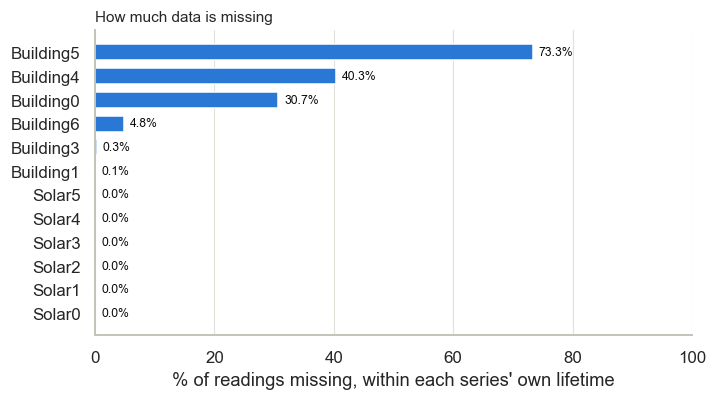

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.6))
order = missing_pct.sort_values()
bars = ax.barh(order.index, order.to_numpy(), color=BLUE, height=0.68)
for y, v in enumerate(order.to_numpy()):
    ax.text(v + 1, y, f"{v}%", va="center", fontsize=8, color=INK)
ax.set_xlim(0, 100)
ax.set_xlabel("% of readings missing, within each series' own lifetime")
ax.set_title("How much data is missing", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y")
plt.show()

**All six solar series are 100% complete.** Whatever logs the panels never drops a
reading, so solar is purely a modelling problem with no data-repair work attached.

The buildings split into three groups: Building1, Building3 and Building6 are
essentially complete; Building0 is missing about a third; and Building4 and
Building5 are missing 40% and 73%. But the percentage alone is misleading — the
next two charts show why Building0 and Building4, which look comparably bad here,
need completely different treatment.

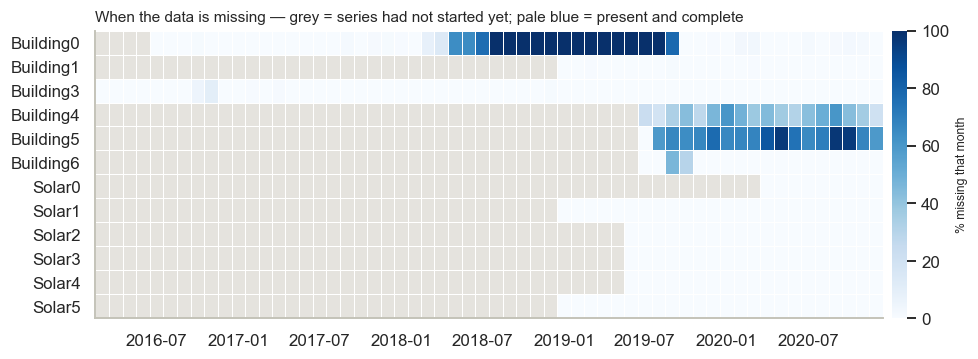

In [16]:
# WHEN is the data missing?
monthly = gaps.resample("MS").mean() * 100

# Grey means "this series did not exist yet", which is different from a pale blue
# "existed and lost nothing". Without this the solar rows and the empty years
# would look identical.
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("#e5e3de")

fig, ax = plt.subplots(figsize=(11, 3.4))
mesh = ax.pcolormesh(monthly.index, np.arange(len(monthly.columns)),
                     np.ma.masked_invalid(monthly.T.to_numpy()),
                     cmap=cmap, vmin=0, vmax=100, shading="nearest",
                     edgecolors="white", linewidth=0.4)
ax.set_yticks(np.arange(len(monthly.columns)), monthly.columns)
ax.invert_yaxis()
ax.grid(False)
cb = fig.colorbar(mesh, ax=ax, pad=0.01)
cb.set_label("% missing that month", fontsize=8)
cb.outline.set_visible(False)
ax.set_title("When the data is missing — grey = series had not started yet; "
             "pale blue = present and complete", loc="left")
plt.show()

Now the difference is obvious. **Building0's missing data is one enormous dark
block** running from mid-2018 to late-2019 — not a data-quality problem so much as
a period where the meter was simply off. Building4 and Building5, by contrast, are
a consistent medium blue across their whole lifetime: their loss is spread evenly
rather than concentrated.

In [17]:
# WHAT SHAPE are the gaps? Measure the length of each run of consecutive NaNs.
def gap_lengths(series):
    isna = series.isna().to_numpy()
    if not isna.any():
        return np.array([], dtype=int)
    # Find where runs of True start and stop.
    edges = np.diff(np.concatenate(([0], isna.view(np.int8), [0])))
    return np.flatnonzero(edges == -1) - np.flatnonzero(edges == 1)


rows = []
for c in df.columns:
    lengths = gap_lengths(tsf["nov"][c])
    if len(lengths) == 0:
        rows.append({"series": c, "n gaps": 0, "median gap": 0, "longest gap": "-",
                     "gaps >= 1 day": 0, "% of loss in long gaps": 0.0})
        continue
    long_gaps = lengths[lengths >= 96]          # 96 steps = one full day
    rows.append({
        "series": c,
        "n gaps": len(lengths),
        "median gap": int(np.median(lengths)),          # in 15-min steps
        "longest gap": f"{lengths.max() / 96:.1f} days",
        "gaps >= 1 day": int(len(long_gaps)),
        "% of loss in long gaps": round(100 * long_gaps.sum() / lengths.sum(), 1),
    })

pd.DataFrame(rows).set_index("series")

,n gaps,median gap,longest gap,gaps >= 1 day,% of loss in long gaps
series,,,,,
Building0,62,10,441.2 days,6,97.4
Building1,9,3,0.3 days,0,0.0
Building3,23,1,4.7 days,1,79.2
Building4,11696,1,0.3 days,0,0.0
Building5,363,50,14.9 days,91,68.2
Building6,21,2,23.2 days,1,98.1
Solar0,0,0,-,0,0.0
Solar1,0,0,-,0,0.0
Solar2,0,0,-,0,0.0


**This table is the one that decides what you do.** Read the last column — it says
what fraction of each series' missing data sits in gaps of a day or longer.

- **Building0** — 62 gaps, but 97% of the loss is in long ones, and the longest is
  **441 days**. This is a structural outage. Do not interpolate it; instead train
  only on the segment after it ends. A 441-day hole is also long enough that the
  building's usage pattern may have genuinely changed across it, so bridging the
  two eras assumes something you have not checked.
- **Building6** — the same story in miniature: 98% of its small loss is a single
  23-day outage. Once you drop or ignore that window, the series is clean.
- **Building4** — the opposite: 11,696 separate gaps with a **median length of 1
  step**, and none reaching a day. These are isolated dropped readings and
  interpolate cleanly. Its 40% headline number is much less alarming than it looks.
- **Building5** — the genuinely hard case. Not one outage but 91 separate gaps of a
  day or more, scattered throughout. There is no clean segment to retreat to.

Building0's longest gap: 2018-07-10 -> 2019-09-24  (441 days)


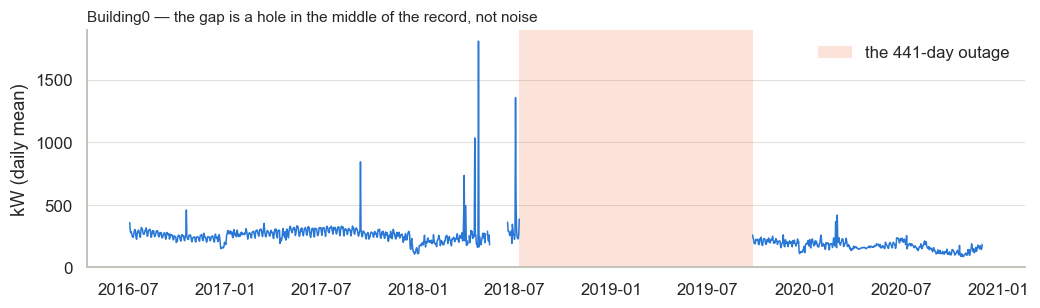


Usable history after the outage: 2019-09-24 onwards, 41,255 readings, 1.0% missing


In [18]:
# Look directly at Building0's outage rather than trusting the summary.
b0 = tsf["nov"]["Building0"].tz_convert(LOCAL_TZ)
lengths = gap_lengths(b0)
isna = b0.isna().to_numpy()
starts = np.flatnonzero(np.diff(np.concatenate(([0], isna.view(np.int8), [0]))) == 1)
biggest = starts[lengths.argmax()]

print(f"Building0's longest gap: {b0.index[biggest]:%Y-%m-%d} -> "
      f"{b0.index[biggest + lengths.max() - 1]:%Y-%m-%d}  ({lengths.max() / 96:.0f} days)")

fig, ax = plt.subplots(figsize=(11, 2.8))
daily = b0.resample("D").mean()
ax.plot(daily.index, daily.to_numpy(), color=BLUE, lw=1.0)
ax.axvspan(b0.index[biggest], b0.index[biggest + lengths.max() - 1],
           color=ORANGE, alpha=0.18, lw=0, label="the 441-day outage")
ax.set_ylabel("kW (daily mean)")
ax.set_title("Building0 — the gap is a hole in the middle of the record, not noise",
             loc="left")
ax.grid(True, axis="y"); ax.legend(loc="upper right")
plt.show()

usable = b0.loc[b0.index[biggest + lengths.max()]:]
print(f"\nUsable history after the outage: {usable.index[0]:%Y-%m-%d} onwards, "
      f"{usable.notna().sum():,} readings, {100 * usable.isna().mean():.1f}% missing")

In [19]:
# Finally: is anything missing inside the months we are scored on?
scored = pd.DataFrame({
    "Oct 2020 missing %": (test_oct.isna().mean() * 100).round(1),
    "Nov 2020 missing %": (test_nov.isna().mean() * 100).round(1),
})
scored

,Oct 2020 missing %,Nov 2020 missing %
series,,
Building0,2.1,1.9
Building1,0.0,0.0
Building3,0.0,0.2
Building4,43.2,35.8
Building5,95.5,66.7
Building6,0.1,0.2
Solar0,0.0,0.0
Solar1,0.0,0.0
Solar2,0.0,0.0


**Building5 is ~96% absent in October and ~67% in November** — the ground truth
you are scored against barely exists. Building4 is 40%-ish missing in both.

This changes how you should think about those two series. You are not being
measured on how well you track a signal; you are being measured on a handful of
surviving points. Sophisticated modelling has little to grip, and an elaborate
model can easily score *worse* than a flat seasonal average by being confidently
wrong on the few readings that count.

## What to do — a per-series plan

| Series | Missing | Treatment |
|---|---|---|
| Solar0–5 | 0% | Nothing needed |
| Building1, Building3 | ~0% | Nothing needed |
| Building6 | 4.8% | Drop the single 23-day outage; interpolate the rest |
| Building4 | 40% | Interpolate — gaps are single steps. Check it is a real load, not a stuck sensor |
| Building0 | 31% | Train only on post-outage data (2019-10 onwards); do not bridge the gap |
| Building5 | 73% | Simple, robust forecast (seasonal profile). Do not over-model |

**A rule worth adopting:** interpolate short gaps, truncate around long ones, and
never interpolate across a gap longer than the seasonal cycle you are trying to
learn. Filling a week-long hole with a straight line teaches the model that
demand is flat for a week.

**One caution for later.** When you interpolate, do it on the training data only,
and never fill forwards across the boundary into October or November. Filling test
gaps with interpolated values would mean scoring your model against numbers you
invented.

---

# 8. All 12 series on one time axis

Section 7 answered *how much* is missing per series. This section answers a
different question: **when is each series available, relative to the others?**

That matters for anything that learns across series — a global model, a shared
embedding, or even just a fair comparison — because those need a window where the
relevant series all exist simultaneously. A series can be 100% complete and still
be nearly useless for cross-learning if it only starts a few months before the
forecast window.

In [20]:
# Daily coverage: what fraction of each day's 96 readings is present.
present = (~df.isna()).resample("D").mean()

# Which days fall inside each series' own lifetime (vs. before it ever started).
existed = lifespan.resample("D").max().astype(bool)

# Mask the pre-start period so it renders as grey rather than as "0% present".
coverage = present.where(existed)

# When does every series exist at once? That is the binding constraint on any
# model that learns across all 12 together.
starts = pd.Series({c: tsf["nov"][c].index[0].tz_convert(LOCAL_TZ) for c in df.columns})
all_start = starts.max()
buildings_start = starts[BUILDINGS].max()

print("First reading of each series:")
print(starts.sort_values().dt.strftime("%Y-%m-%d").to_string())
print(f"\nAll 6 buildings coexist from : {buildings_start:%Y-%m-%d}")
print(f"All 12 series coexist from   : {all_start:%Y-%m-%d}  "
      f"({(pd.Timestamp('2020-10-01', tz=LOCAL_TZ) - all_start).days} days before the Oct window)")

First reading of each series:
Building3    2016-03-01
Building0    2016-07-04
Solar1       2019-01-01
Building1    2019-01-10
Solar5       2019-01-16
Solar2       2019-06-06
Solar3       2019-06-06
Solar4       2019-06-06
Building4    2019-07-03
Building6    2019-07-25
Building5    2019-07-26
Solar0       2020-04-26

All 6 buildings coexist from : 2019-07-26
All 12 series coexist from   : 2020-04-26  (158 days before the Oct window)


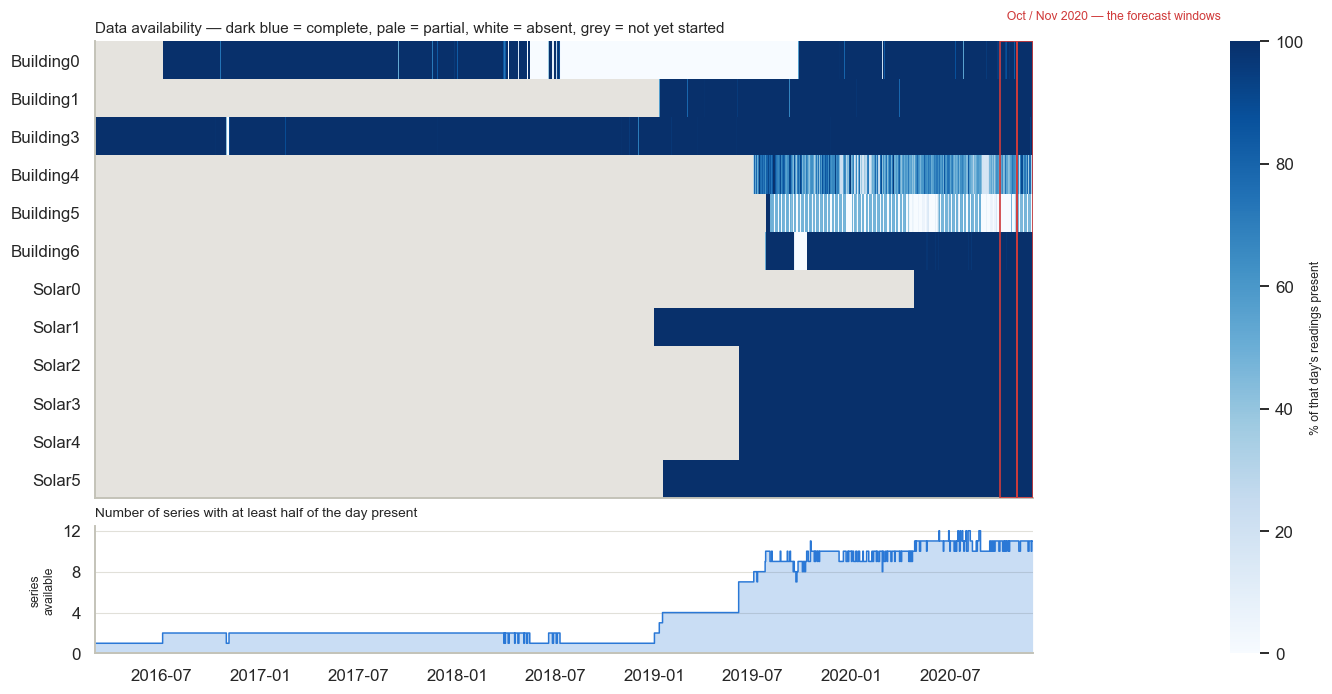

In [21]:
fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(12, 6.2), height_ratios=[5, 1.4], sharex=True,
    constrained_layout=True)

cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("#e5e3de")            # grey = series did not exist yet

mesh = ax.pcolormesh(coverage.index, np.arange(len(coverage.columns)),
                     np.ma.masked_invalid(coverage.T.to_numpy()) * 100,
                     cmap=cmap, vmin=0, vmax=100, shading="nearest")
ax.set_yticks(np.arange(len(coverage.columns)), coverage.columns)
ax.invert_yaxis()
ax.grid(False)

# Mark the two months we have to forecast.
for lo, hi in (OCT, NOV):
    ax.axvspan(lo, hi, facecolor="none", edgecolor="#d03b3b", lw=1.1, zorder=5)
ax.text(OCT[0], -1.0, "  Oct / Nov 2020 — the forecast windows",
        color="#d03b3b", fontsize=8, va="bottom")

cb = fig.colorbar(mesh, ax=[ax, ax2], pad=0.01)
cb.set_label("% of that day's readings present", fontsize=8)
cb.outline.set_visible(False)
ax.set_title("Data availability — dark blue = complete, pale = partial, "
             "white = absent, grey = not yet started", loc="left")

# How many series are usable on any given day?
usable = (coverage.fillna(0) >= 0.5).sum(axis=1)
ax2.fill_between(usable.index, usable.to_numpy(), step="mid", color="#2a78d6", alpha=0.25, lw=0)
ax2.plot(usable.index, usable.to_numpy(), color="#2a78d6", lw=1.0, drawstyle="steps-mid")
ax2.set_ylim(0, 12.5)
ax2.set_yticks([0, 4, 8, 12])
ax2.set_ylabel("series\navailable", fontsize=8)
ax2.grid(True, axis="y")
ax2.set_title("Number of series with at least half of the day present", loc="left", fontsize=9)
plt.show()

**What the chart shows.**

Read down any vertical line to see which series existed at that moment. The two
red rectangles are the months you have to forecast.

The most consequential fact is the **staircase on the left**: the series switch on
at very different dates, so the amount of history they share is far smaller than
any individual series' length suggests. Building3 has nearly five years, but the
window where *all twelve* overlap is only the last few months before the forecast
period — Solar0 is the binding constraint, and it is the newest series by a wide
margin.

The bottom strip makes the practical consequence concrete: the count of usable
series only reaches its maximum quite late. If you build a single model across all
12 series, that late date is all the training data it can have. Two ways around it:
train per series (each uses its own full history), or train across a *subset*
chosen so the shared window is long enough to be worth having.

The other thing worth noticing is that **Building4 and Building5 are pale
throughout** rather than dark-with-white-holes. Their loss is not concentrated in
an era you can cut away — it is spread through every month they exist, which is
exactly what made them different from Building0 in the previous section.

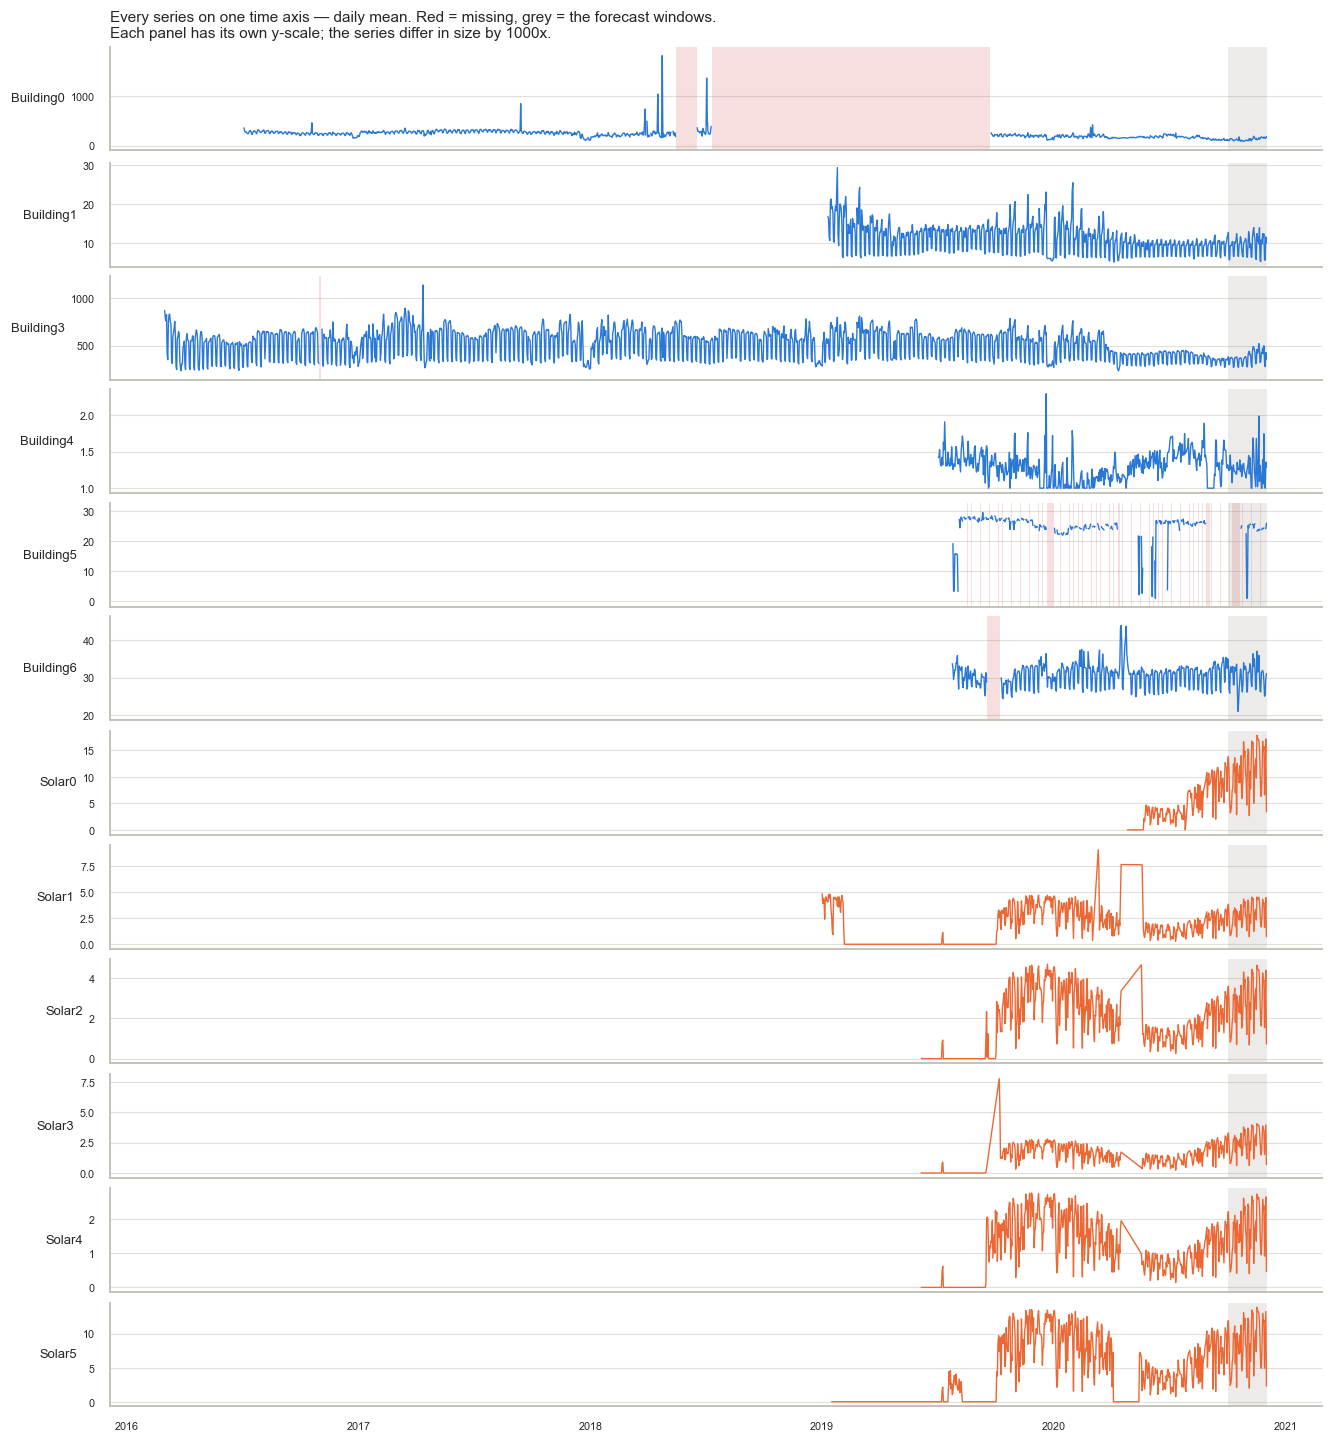

In [22]:
# The same time axis, now showing the actual values. Gaps appear as breaks in the
# line, so you can see the data and its holes together.
fig, axes = plt.subplots(len(df.columns), 1, figsize=(12, 13), sharex=True,
                         constrained_layout=True)

daily_mean = df.resample("D").mean()

for ax, col in zip(axes, df.columns):
    colour = "#2a78d6" if col.startswith("Building") else "#eb6834"
    ax.plot(daily_mean.index, daily_mean[col].to_numpy(), color=colour, lw=0.9)

    # Shade days that are entirely absent but inside the series' lifetime.
    absent = (coverage[col] == 0)
    if absent.any():
        ax.fill_between(coverage.index, 0, 1, where=absent.to_numpy(),
                        transform=ax.get_xaxis_transform(),
                        color="#d03b3b", alpha=0.16, lw=0)

    for lo, hi in (OCT, NOV):
        ax.axvspan(lo, hi, color="#898781", alpha=0.16, lw=0)

    ax.set_ylabel(col, rotation=0, ha="right", va="center", fontsize=8.5)
    ax.grid(True, axis="y")
    ax.tick_params(labelsize=7)

axes[0].set_title("Every series on one time axis — daily mean. Red = missing, "
                  "grey = the forecast windows.\nEach panel has its own y-scale; "
                  "the series differ in size by 1000x.", loc="left", fontsize=10)
plt.show()

Each panel keeps its own y-scale deliberately. Building4 peaks around 5 kW and
Building3 around 8,556 kW, so a shared scale would flatten ten of the twelve
panels into flat lines, and a second y-axis would make two unrelated scales look
comparable. The trade-off is that you can compare *shape* and *timing* down the
column, but not magnitude — for magnitude, read the summary table in section 2.

Lined up this way, three things stand out that were invisible series-by-series:

- **The solar series move together**, with the same seasonal envelope, because
  they sit on one campus under one sky. That is exactly the redundancy a global
  model across the solar panels could exploit — and unlike the buildings, they
  share a long clean overlap.
- **Building0's outage sits in the middle of its record**, while Building4's and
  Building5's red is stippled throughout theirs.
- **Nothing is missing from the forecast windows for the solar series or for
  Buildings 1, 3 and 6** — the grey bands are clean for eight of the twelve.

Window where all 12 series exist: 2020-04-26 -> 2020-12-01 (21,064 rows, 219 days)


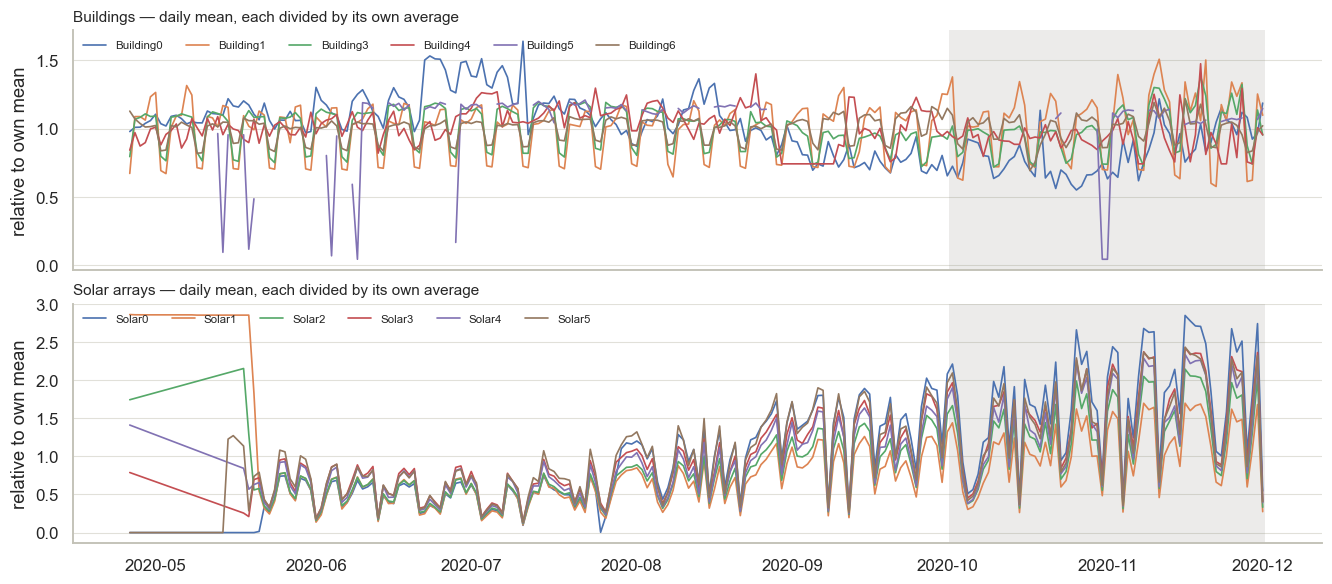

In [23]:
# Zoom on the window where all 12 series coexist - the realistic span for any
# model that learns across every series at once.
recent = df.loc[all_start:]

fig, axes = plt.subplots(2, 1, figsize=(12, 5.2), sharex=True, constrained_layout=True)

for col in BUILDINGS:
    s = recent[col].resample("D").mean()
    axes[0].plot(s.index, (s / s.mean()).to_numpy(), lw=1.1, label=col)
for col in SOLAR:
    s = recent[col].resample("D").mean()
    axes[1].plot(s.index, (s / s.mean()).to_numpy(), lw=1.1, label=col)

for ax, title in zip(axes, ["Buildings", "Solar arrays"]):
    for lo, hi in (OCT, NOV):
        ax.axvspan(lo, hi, color="#898781", alpha=0.16, lw=0)
    ax.set_title(f"{title} — daily mean, each divided by its own average", loc="left")
    ax.set_ylabel("relative to own mean")
    ax.grid(True, axis="y")
    ax.legend(ncol=6, fontsize=7.5, loc="upper left")

print(f"Window where all 12 series exist: {all_start:%Y-%m-%d} -> {df.index[-1]:%Y-%m-%d} "
      f"({len(recent):,} rows, {(df.index[-1] - all_start).days} days)")
plt.show()

Dividing each series by its own mean is what makes them comparable on one axis
without a second y-scale. Now the question "do these move together?" is answerable
by eye: the solar arrays track each other closely, while the buildings are far
more independent — they respond to their own occupancy rather than to a shared
driver.

That difference is a genuine modelling result, not just a picture. It suggests
pooling the solar series is likely to help, and pooling the buildings is likely to
hurt.

---

# 9. Hidden bad data — "complete" is not the same as "correct"

Section 7 concluded that all six solar series are 100% complete. That is true and
also misleading. **A reading being present does not make it valid.** The `?`
markers only tell you where the data provider *knew* a value was absent; they say
nothing about periods where a sensor reported confidently wrong numbers.

Solar gives us a free way to check, because physics supplies a ground truth:
**a solar panel produces exactly zero at night.** Any non-zero reading between
22:00 and 04:00 local time is impossible, so it is a defect — no modelling
assumptions required.

This kind of physically-grounded validity check is worth more than any outlier
statistic, because it cannot produce a false positive.

In [24]:
# Solar output at night must be zero. 22:00-04:00 is dark year-round in Melbourne
# even at the summer solstice, so this test is safe in both seasons.
night = df.between_time("22:00", "04:00")[SOLAR]
night_max = night.groupby(night.index.normalize()).max()

bad_days = night_max > 0.01          # tolerance for float noise
report = pd.DataFrame({
    "days with output at night": bad_days.sum(),
    "days observed": night_max.notna().sum(),
})
report["% of days invalid"] = (100 * report.iloc[:, 0] / report.iloc[:, 1]).round(1)
report["first bad day"] = [
    f"{bad_days.index[bad_days[c].fillna(False)][0]:%Y-%m-%d}" if bad_days[c].any() else "-"
    for c in SOLAR]
report["last bad day"] = [
    f"{bad_days.index[bad_days[c].fillna(False)][-1]:%Y-%m-%d}" if bad_days[c].any() else "-"
    for c in SOLAR]
report

,days with output at night,days observed,% of days invalid,first bad day,last bad day
series,,,,,
Solar0,26,220,11.8,2020-05-24,2020-10-05
Solar1,47,701,6.7,2020-03-02,2020-05-20
Solar2,39,545,7.2,2019-10-09,2020-05-19
Solar3,62,545,11.4,2019-09-16,2020-05-19
Solar4,35,545,6.4,2020-04-15,2020-05-19
Solar5,0,686,0.0,-,-


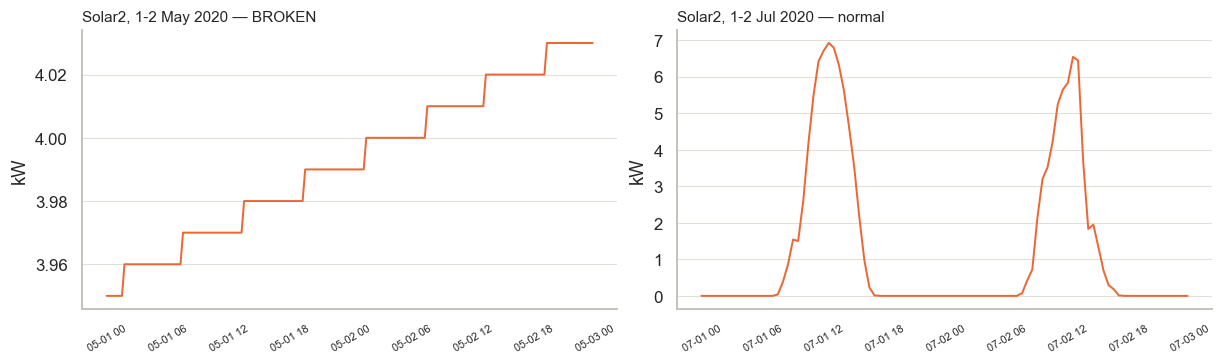

2020-05-01 00:00:00+10:00    3.95
2020-05-01 00:15:00+10:00    3.95
2020-05-01 00:30:00+10:00    3.95
2020-05-01 00:45:00+10:00    3.95
2020-05-01 01:00:00+10:00    3.95
2020-05-01 01:15:00+10:00    3.95
2020-05-01 01:30:00+10:00    3.95
2020-05-01 01:45:00+10:00    3.96
2020-05-01 02:00:00+10:00    3.96
2020-05-01 02:15:00+10:00    3.96
2020-05-01 02:30:00+10:00    3.96
2020-05-01 02:45:00+10:00    3.96
2020-05-01 03:00:00+10:00    3.96
Freq: 15min


In [25]:
# Look at the worst offender directly. Two days from the middle of Solar2's
# affected period, plotted against a known-good period for comparison.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), constrained_layout=True)

for ax, (span, label) in zip(axes, [
        (slice("2020-05-01", "2020-05-02"), "Solar2, 1-2 May 2020 — BROKEN"),
        (slice("2020-07-01", "2020-07-02"), "Solar2, 1-2 Jul 2020 — normal")]):
    seg = df.loc[span, "Solar2"]
    ax.plot(seg.index, seg.to_numpy(), color="#eb6834", lw=1.3)
    ax.set_title(label, loc="left")
    ax.set_ylabel("kW")
    ax.grid(True, axis="y")
    ax.tick_params(axis="x", rotation=30, labelsize=7)
plt.show()

print(df.loc["2020-05-01 00:00":"2020-05-01 03:00", "Solar2"].to_string())

**The broken panel has no day/night cycle at all.** It sits around 3.95–4.03 kW
and creeps upward monotonically, including all through the night. That is not
power output — it looks like a **cumulative energy counter** (kWh accumulated
since reset) that has been written into a column that is supposed to hold
instantaneous kW, or a sensor stuck in a fault mode.

Crucially, **none of it is flagged with `?`**. It is silently wrong. Had we
trained on it, the model would have learned that Solar2 sometimes generates 4 kW
at 3am.

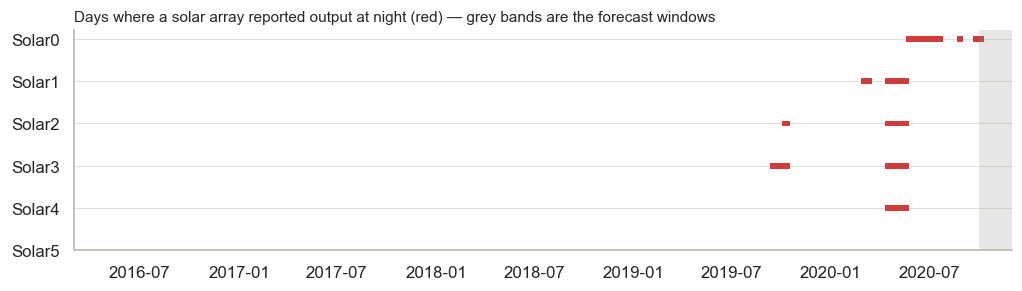

Invalid days falling inside October/November 2020:
series
Solar0    2
Solar1    0
Solar2    0
Solar3    0
Solar4    0
Solar5    0


In [26]:
# When are the defects, and do any land in the months we forecast?
fig, ax = plt.subplots(figsize=(11, 2.6))
for i, col in enumerate(SOLAR):
    days = bad_days.index[bad_days[col].fillna(False)]
    if len(days):
        ax.scatter(days, np.full(len(days), i), s=14, marker="s",
                   color="#d03b3b", edgecolors="none")
ax.set_yticks(range(len(SOLAR)), SOLAR)
ax.invert_yaxis()
for lo, hi in (OCT, NOV):
    ax.axvspan(lo, hi, color="#898781", alpha=0.2, lw=0)
ax.set_xlim(df.index[0], df.index[-1])
ax.grid(True, axis="y")
ax.set_title("Days where a solar array reported output at night (red) — "
             "grey bands are the forecast windows", loc="left")
plt.show()

in_window = bad_days.loc[(bad_days.index >= OCT[0]) & (bad_days.index < NOV[1])].sum()
print("Invalid days falling inside October/November 2020:")
print(in_window.to_string())

**The good news is the timing.** Almost all of the corruption sits in 2019 and the
first half of 2020, and only Solar0 has any inside the forecast windows. So this
damages your *training* data rather than the data you are scored against.

**What to do.** Treat these periods as missing rather than deleting the series:
set the affected days to `NaN` before training so the model never sees them. That
is a two-line fix once you have the `bad_days` table above.

**The wider lesson for the report.** The `?` markers are the provider's account of
what is missing, and they are incomplete. Before trusting any series, test it
against something you know must be true:

- Solar output is zero at night, and never exceeds the array's physical capacity.
- Building demand is never negative, and a real building is never *perfectly*
  flat for hours — a long run of identical values means a stuck sensor, not
  steady consumption. (Recall from section 2 that Building4 only ever reports
  values between 1.0 and 5.0 — worth applying exactly this suspicion to.)
- Readings should not jump by more than the equipment physically can.

Each of those is a rule you can state before looking at the data, which is what
separates a data-quality check from post-hoc outlier removal.

---

# 10. Preparing solar + weather for a production model

The goal: one tidy table where each row is *one array at one hourly stamp*, with
the production we want to predict alongside the weather that explains it.

## Decision 1 — resample solar down to hourly

Solar is recorded every **15 minutes**; ERA5 is **hourly**. They cannot be joined
until they share a resolution, and there are two directions: downsample solar, or
interpolate ERA5 up.

**We downsample solar to hourly.** Since this project is not being run as the
original competition, there is no 15-minute submission format forcing our hand,
and the objective — predict solar production — is unchanged by the choice of
resolution.

Going hourly buys three things:

- **The weather join becomes exact.** At 15 minutes we would have to *invent*
  intermediate weather values by interpolation. At hourly resolution each ERA5
  record lines up with exactly one solar bucket, with nothing approximated.
- **Less noise in the target.** A 15-minute reading catches individual clouds
  crossing the panel, which is close to unpredictable from a reanalysis grid
  point. Averaging to the hour removes variance the weather data was never able
  to explain.
- **Four times fewer rows**, which makes every model faster to fit.

The cost is real but small, and the next cell measures it rather than assuming it.

In [27]:
# What does hourly averaging discard? Compare the true 15-minute series against
# the hourly step-function that replaces it.
print("Variance of the 15-minute signal retained by the hourly average:\n")
for c in SOLAR:
    s = df[c].dropna()
    expanded = s.resample("h").mean().reindex(s.index, method="ffill")
    r2 = 1 - ((s - expanded) ** 2).sum() / ((s - s.mean()) ** 2).sum()
    print(f"  {c}:  R^2 = {r2:.4f}   ({100 * (1 - r2):.1f}% is sub-hourly detail)")

Variance of the 15-minute signal retained by the hourly average:

  Solar0:  R^2 = 0.9788   (2.1% is sub-hourly detail)
  Solar1:  R^2 = 0.9873   (1.3% is sub-hourly detail)
  Solar2:  R^2 = 0.9830   (1.7% is sub-hourly detail)
  Solar3:  R^2 = 0.9832   (1.7% is sub-hourly detail)
  Solar4:  R^2 = 0.9829   (1.7% is sub-hourly detail)
  Solar5:  R^2 = 0.9825   (1.8% is sub-hourly detail)


Only 1.3–2.1% of the variation is sub-hourly. That is the part driven by
individual clouds — precisely the part a single hourly reanalysis grid point was
never going to predict — so we lose very little that was actually forecastable.

## Decision 2 — line the two clocks up

ERA5's radiation variables are **accumulations over the preceding hour**, stamped
at the *end* of the period. A record labelled `12:00` describes the sunlight that
fell between 11:00 and 12:00.

Pandas resampling labels buckets by their *left* edge, so the solar bucket
covering that same span is labelled `11:00`. The two describe an identical hour
under different names, and joining on the raw label pairs each ERA5 record with
the wrong hour of production.

Shifting ERA5 back by exactly 60 minutes makes the labels agree — and because
both then refer to the same clock hour, this is an **exact interval match with no
interpolation at all**. The cell below verifies it against the data.

In [28]:
ERA5_SHIFT = pd.Timedelta(hours=-1)   # accumulations are stamped at the END of their hour

# Solar5 is the reference: section 9 showed it is the only array with no invalid
# night-time readings, so it is the cleanest yardstick.
probe = df["Solar5"].loc["2019-07-01":"2020-11-30"].resample("h").mean()
radiation = era5["surface_solar_radiation"]

for label, shift in [("raw label (no shift)", pd.Timedelta(0)),
                     ("shifted back one hour", ERA5_SHIFT)]:
    aligned = radiation.copy()
    aligned.index = aligned.index + shift
    paired = pd.DataFrame({"production": probe,
                           "radiation": aligned.reindex(probe.index)}).dropna()
    print(f"{label:24s} corr = {paired['production'].corr(paired['radiation']):.5f}  "
          f"({len(paired):,} paired hours)")

raw label (no shift)     corr = 0.80626  (12,455 paired hours)
shifted back one hour    corr = 0.85782  (12,455 paired hours)


The corrected join is markedly better, and it is better for a reason we could
state in advance rather than something discovered by search. That distinction
matters in the write-up: this is a fix derived from how ERA5 is defined, not a
parameter tuned until the number improved.

## Decision 3 — arrays that were switched off report zero, not missing

Now that production and radiation share a clock, a third problem becomes visible,
and it is the largest one in this section.

Section 7 found the solar series to be 100% complete, and section 9 found
nonsense night-time values in five of them. This is a third failure mode: hours
where the sun was **demonstrably bright** and the array returned **exactly zero**.
A panel under 800 W/m² of sunshine does not produce nothing. The array was off —
under maintenance, not yet commissioned, or disconnected — and the logger recorded
a confident zero instead of a missing value.

In [29]:
BRIGHT_WM2 = 200        # above this the sun is definitely up and shining
MIN_BRIGHT_HOURS = 4    # a day needs this many bright hours before we judge it

# How often is the sun bright while an array reports exactly nothing?
probe_weather = era5.copy()
probe_weather.index = probe_weather.index + ERA5_SHIFT
rad_h = probe_weather["surface_solar_radiation"]

rows = []
for name in SOLAR:
    hourly = df[name].resample("h").mean()
    paired = pd.DataFrame({"p": hourly, "r": rad_h.reindex(hourly.index)}).dropna()
    bright = paired[paired["r"] > BRIGHT_WM2]
    zero = bright["p"] == 0
    by_day = bright.groupby(bright.index.normalize())
    dead_days = (by_day["p"].apply(lambda g: (g == 0).all()) & (by_day.size() >= MIN_BRIGHT_HOURS))
    rows.append({
        "array": name,
        "bright hours": len(bright),
        "zero while bright": int(zero.sum()),
        "%": round(100 * zero.mean(), 1),
        "fully offline days": int(dead_days.sum()),
    })
pd.DataFrame(rows).set_index("array")

,bright hours,zero while bright,%,fully offline days
array,,,,
Solar0,1470,131,8.9,19
Solar1,5420,1638,30.2,218
Solar2,4116,677,16.4,95
Solar3,4116,559,13.6,85
Solar4,4116,560,13.6,84
Solar5,5252,1963,37.4,251


**Between 9% and 37% of bright hours** are affected, which is far too large to
ignore — and the pattern says plainly that these are outages rather than scattered
glitches. On 231 of the 234 affected dates, *every single* bright hour is zero: the
array was down for the whole day, not flickering.

Two details confirm the reading. The longest run for Solar5 is 1,297 consecutive
bright hours. And the block starting **29 August 2019 appears in five arrays at
once** — a site-wide event, not six independent sensor faults.

Most of it sits in 2019, when the arrays were being commissioned, which is also
why Solar0 opens with 25 days of pure zeros. **None of it falls in October or
November 2020**, so the forecast windows are clean; the damage is confined to
training data.

The rule below marks a day offline when the sun was bright for at least four hours
and the array returned exactly zero in every one of them, then blanks that day.
Note this is deliberately conservative: it needs a *whole day* of evidence, so a
genuinely dark stormy day can never trigger it.

## Building the table

In [30]:
# The ERA5 grid point, from the "coordinates" column dropped back in section 3.
LAT, LON = -37.91, 145.13
MIN_READINGS_PER_HOUR = 3   # of a possible 4; below this the hourly mean is unreliable
# BRIGHT_WM2 and MIN_BRIGHT_HOURS were defined with the offline analysis above.


def solar_elevation(timestamps):
    """Sun elevation in degrees. A pure function of time and place, so it is
    always available for future timestamps - no weather forecast required."""
    utc = timestamps.tz_convert("UTC")
    doy = utc.dayofyear.to_numpy()
    hours = utc.hour.to_numpy() + utc.minute.to_numpy() / 60
    g = 2 * np.pi / 365.25 * (doy - 1 + (hours - 12) / 24)
    declination = (0.006918 - 0.399912 * np.cos(g) + 0.070257 * np.sin(g)
                   - 0.006758 * np.cos(2 * g) + 0.000907 * np.sin(2 * g)
                   - 0.002697 * np.cos(3 * g) + 0.001480 * np.sin(3 * g))
    eq_time = 229.18 * (0.000075 + 0.001868 * np.cos(g) - 0.032077 * np.sin(g)
                        - 0.014615 * np.cos(2 * g) - 0.040849 * np.sin(2 * g))
    hour_angle = np.deg2rad(((hours * 60 + eq_time + 4 * LON) % 1440) / 4 - 180)
    lat = np.deg2rad(LAT)
    sin_elev = (np.sin(lat) * np.sin(declination)
                + np.cos(lat) * np.cos(declination) * np.cos(hour_angle))
    return np.rad2deg(np.arcsin(np.clip(sin_elev, -1, 1)))


def build_solar_dataset(arrays=SOLAR, drop_invalid=True):
    """One row per (array, hour): hourly mean production plus aligned weather."""

    # --- Target: 15-minute production -> hourly mean kW -----------------------
    # Mean, not sum: these are power readings (kW), so the hourly mean is the
    # average power over that hour. A sum would silently change the units.
    production = {}
    for name in arrays:
        s = df[name].copy()

        # Section 9: days where an array reported output at night are sensor
        # faults. Blank the whole day - a faulty sensor's daytime readings are
        # not trustworthy either.
        if drop_invalid and name in bad_days.columns:
            faulty = bad_days.index[bad_days[name].fillna(False)]
            s = s.mask(s.index.normalize().isin(faulty))

        hourly = s.resample("h").mean()
        # Discard hours built from too few surviving 15-minute readings.
        hourly = hourly.where(s.resample("h").count() >= MIN_READINGS_PER_HOUR)
        production[name] = hourly

    production = pd.DataFrame(production)
    index = production.index

    # --- Weather: shift onto the hour it actually describes, then align -------
    shifted = era5.copy()
    shifted.index = shifted.index + ERA5_SHIFT
    weather = shifted.reindex(index)          # exact match, no interpolation

    # --- Remove offline periods ----------------------------------------------
    # An array that is switched off reports 0, not NaN. A day where the sun was
    # bright for hours and the array returned exactly zero every time was not a
    # dark day - the array was down. Left in, these teach the model that full
    # sunshine sometimes yields nothing.
    if drop_invalid:
        bright = weather["surface_solar_radiation"] > BRIGHT_WM2
        day_of = pd.Series(index.normalize(), index=index)
        for name in arrays:
            p = production[name]
            judged = p.notna() & bright
            counts = pd.DataFrame({
                "day": day_of, "bright": judged, "zero": judged & (p == 0),
            }).groupby("day")[["bright", "zero"]].sum()
            offline = counts.index[(counts["bright"] >= MIN_BRIGHT_HOURS)
                                   & (counts["zero"] == counts["bright"])]
            production[name] = p.mask(day_of.isin(offline))

    # --- Solar geometry, evaluated at the MIDPOINT of each hour ---------------
    # The bucket labelled 11:00 spans 11:00-12:00, so the sun position that
    # represents it is the one at 11:30. Using the label would bias every
    # elevation by half an hour.
    midpoints = index + pd.Timedelta(minutes=30)
    elevation = solar_elevation(midpoints)
    sin_elev = np.sin(np.deg2rad(elevation))

    weather["solar_elevation"] = elevation
    weather["is_daylight"] = (elevation > 0).astype(int)
    # Clear-sky irradiance: what a cloudless sky would deliver at this sun angle.
    weather["clear_sky_ghi"] = 1361 * np.clip(sin_elev, 0, None) * 0.75
    # Clear-sky index: how much of that actually arrived. Divides out the daily
    # and seasonal envelope, leaving the cloud-driven part - the only genuinely
    # uncertain component. Undefined at night (0/0), where 0 is the sane fill:
    # none expected, none arrived. Night predictions are clamped to zero anyway.
    weather["clear_sky_index"] = (
        weather["surface_solar_radiation"] / weather["clear_sky_ghi"].replace(0, np.nan)
    ).clip(0, 1.5).fillna(0.0)

    # Recent radiation history - cloud cover persists over a few hours.
    for lag in (1, 2, 3):
        weather[f"radiation_lag_{lag}h"] = weather["surface_solar_radiation"].shift(lag)
    weather["radiation_roll_3h"] = weather["surface_solar_radiation"].rolling(3).mean()

    # Calendar terms, encoded cyclically so 23:00 and 00:00 sit adjacent.
    weather["tod_sin"] = np.sin(2 * np.pi * index.hour / 24)
    weather["tod_cos"] = np.cos(2 * np.pi * index.hour / 24)
    weather["doy_sin"] = np.sin(2 * np.pi * index.dayofyear / 365.25)
    weather["doy_cos"] = np.cos(2 * np.pi * index.dayofyear / 365.25)

    # --- Stack the arrays into long format ------------------------------------
    frames = []
    for name in arrays:
        part = weather.copy()
        part.insert(0, "array", name)
        part.insert(1, "production_kw", production[name])
        frames.append(part)

    out = pd.concat(frames).sort_index()
    out.index.name = "hour"
    return out


solar_data = build_solar_dataset()
print(f"{len(solar_data):,} rows x {solar_data.shape[1]} columns "
      f"({solar_data['array'].nunique()} arrays, hourly)")
print(f"span: {solar_data.index.min():%Y-%m-%d %H:%M} -> {solar_data.index.max():%Y-%m-%d %H:%M}")
solar_data.head()

249,960 rows x 22 columns (6 arrays, hourly)
span: 2016-03-01 15:00 -> 2020-12-01 10:00


,array,production_kw,temperature,dewpoint_temperature,wind_speed,mean_sea_level_pressure,relative_humidity,surface_solar_radiation,surface_thermal_radiation,total_cloud_cover,solar_elevation,is_daylight,clear_sky_ghi,clear_sky_index,radiation_lag_1h,radiation_lag_2h,radiation_lag_3h,radiation_roll_3h,tod_sin,tod_cos,doy_sin,doy_cos
hour,,,,,,,,,,,,,,,,,,,,,,
2016-03-01 15:00:00+11:00,Solar0,NaN,30.99,10.72,3.06,101381.97,0.29,774.98,365.04,0.96,49.700591,1,778.500507,0.995478,NaN,NaN,NaN,NaN,-0.707107,-0.707107,0.867099,0.498137
2016-03-01 15:00:00+11:00,Solar2,NaN,30.99,10.72,3.06,101381.97,0.29,774.98,365.04,0.96,49.700591,1,778.500507,0.995478,NaN,NaN,NaN,NaN,-0.707107,-0.707107,0.867099,0.498137
2016-03-01 15:00:00+11:00,Solar5,NaN,30.99,10.72,3.06,101381.97,0.29,774.98,365.04,0.96,49.700591,1,778.500507,0.995478,NaN,NaN,NaN,NaN,-0.707107,-0.707107,0.867099,0.498137
2016-03-01 15:00:00+11:00,Solar4,NaN,30.99,10.72,3.06,101381.97,0.29,774.98,365.04,0.96,49.700591,1,778.500507,0.995478,NaN,NaN,NaN,NaN,-0.707107,-0.707107,0.867099,0.498137
2016-03-01 15:00:00+11:00,Solar1,NaN,30.99,10.72,3.06,101381.97,0.29,774.98,365.04,0.96,49.700591,1,778.500507,0.995478,NaN,NaN,NaN,NaN,-0.707107,-0.707107,0.867099,0.498137


In [31]:
# Confirm the resampling behaved: production should still be non-negative, and
# the hourly peak should land near the middle of the day.
check = solar_data.dropna(subset=["production_kw"])
peak_hour = check.groupby(check.index.hour)["production_kw"].mean().idxmax()
print(f"negative production values : {(check['production_kw'] < 0).sum()}")
print(f"peak production hour       : {peak_hour}:00 local "
      f"({'plausible' if 10 <= peak_hour <= 14 else 'SUSPICIOUS'})")
print(f"peak solar-elevation hour  : {check.groupby(check.index.hour)['solar_elevation'].mean().idxmax()}:00")

usable = check.groupby("array").size()
pd.DataFrame({"usable hours": usable,
              "hours dropped (absent or faulty)": solar_data.groupby("array").size() - usable})

negative production values : 0
peak production hour       : 12:00 local (plausible)
peak solar-elevation hour  : 12:00


,usable hours,hours dropped (absent or faulty)
array,,
Solar0,4187,37473
Solar1,10450,31210
Solar2,9850,31810
Solar3,9539,32121
Solar4,10210,31450
Solar5,10426,31234


## Splitting for training

The same UTC boundaries as section 2. ERA5 covers October and November in full, so
the test splits already have their features populated — only the target needs
predicting.

In [32]:
model_df = solar_data.dropna(subset=["production_kw", "surface_solar_radiation"])

solar_train = model_df.loc[model_df.index < OCT[0]]
solar_oct = model_df.loc[(model_df.index >= OCT[0]) & (model_df.index < OCT[1])]
solar_nov = model_df.loc[(model_df.index >= NOV[0]) & (model_df.index < NOV[1])]

for label, part in [("train", solar_train), ("October", solar_oct), ("November", solar_nov)]:
    print(f"{label:9s} {len(part):>7,} rows   "
          f"{part.index.min():%Y-%m-%d} -> {part.index.max():%Y-%m-%d}")
print(f"\n(October should be 6 arrays x 744 hours = {6 * 744:,} at most; "
      f"November 6 x 720 = {6 * 720:,})")

FEATURES = [c for c in model_df.columns if c not in ("array", "production_kw")]
print(f"\n{len(FEATURES)} feature columns:")
print("  " + ", ".join(FEATURES))

train      45,925 rows   2019-01-01 -> 2020-10-01
October     4,417 rows   2020-10-01 -> 2020-11-01
November    4,320 rows   2020-11-01 -> 2020-12-01

(October should be 6 arrays x 744 hours = 4,464 at most; November 6 x 720 = 4,320)

20 feature columns:
  temperature, dewpoint_temperature, wind_speed, mean_sea_level_pressure, relative_humidity, surface_solar_radiation, surface_thermal_radiation, total_cloud_cover, solar_elevation, is_daylight, clear_sky_ghi, clear_sky_index, radiation_lag_1h, radiation_lag_2h, radiation_lag_3h, radiation_roll_3h, tod_sin, tod_cos, doy_sin, doy_cos


### Check the feature matrix is usable

A single `NaN` in the predictors stops most scikit-learn estimators, and the
failure surfaces much later with an unhelpful message. Assert it here instead.

In [33]:
nulls = model_df[FEATURES].isna().sum()
print("Columns still containing nulls:" if nulls.any() else "No nulls in any feature column.")
if nulls.any():
    print(nulls[nulls > 0].to_string())

rows_with_nulls = int(model_df[FEATURES].isna().any(axis=1).sum())
print(f"rows with at least one null feature: {rows_with_nulls:,} of {len(model_df):,}")

assert rows_with_nulls == 0, "clean the remaining nulls before modelling"
print("\nFeature matrix is model-ready.")

No nulls in any feature column.
rows with at least one null feature: 0 of 54,662

Feature matrix is model-ready.


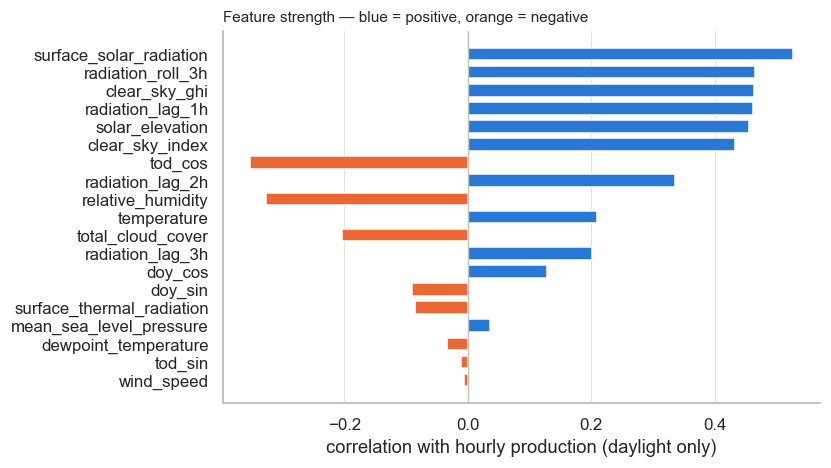

`is_daylight` is absent above because this view is already filtered to
daylight, making it constant. It still matters in the full dataset.


In [34]:
# Which features actually carry signal? Daylight hours only - at night everything
# is trivially zero and would inflate every correlation.
day = solar_train[solar_train["solar_elevation"] > 5]
corr = (day[FEATURES + ["production_kw"]].corr()["production_kw"]
        .drop("production_kw").dropna().sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.barh(corr.index, corr.to_numpy(),
        color=["#2a78d6" if v > 0 else "#eb6834" for v in corr], height=0.7)
ax.axvline(0, color="#c3c2b7", lw=0.9)
ax.invert_yaxis()
ax.set_xlabel("correlation with hourly production (daylight only)")
ax.set_title("Feature strength — blue = positive, orange = negative", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y")
plt.show()

print("`is_daylight` is absent above because this view is already filtered to")
print("daylight, making it constant. It still matters in the full dataset.")

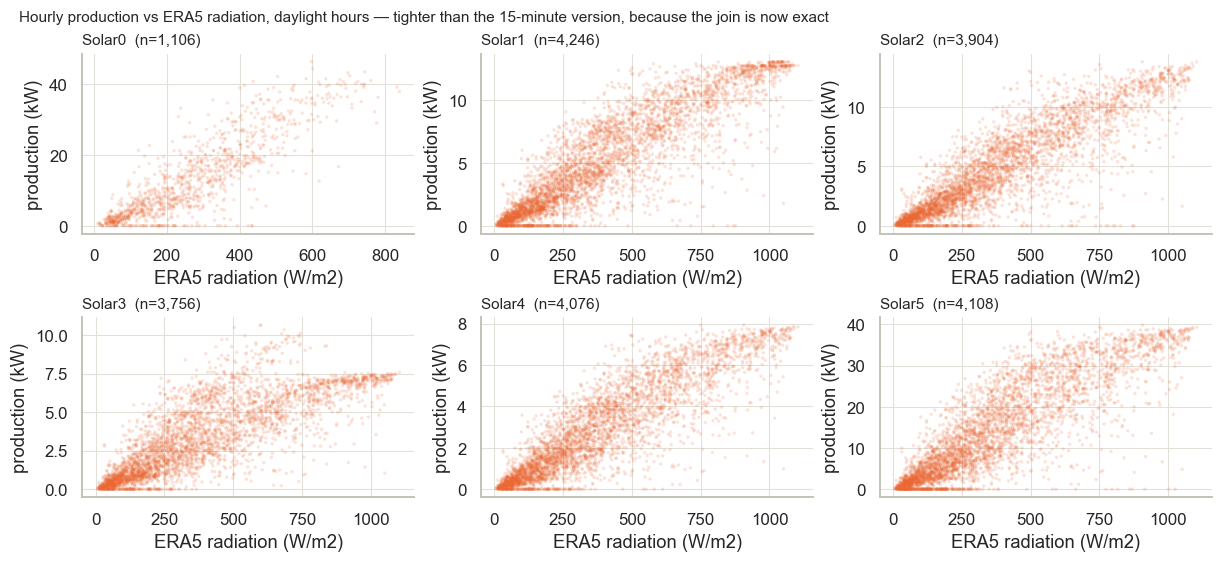

bright hours still reporting exactly zero: 244 (0.53% of training rows)
array
Solar0    12
Solar1    45
Solar2    62
Solar3    29
Solar4    38
Solar5    58


In [35]:
# The core relationship, per array, now that both sides share a clock.
fig, axes = plt.subplots(2, 3, figsize=(11, 5.0), constrained_layout=True)
for ax, name in zip(axes.ravel(), SOLAR):
    d = solar_train[(solar_train["array"] == name) & (solar_train["solar_elevation"] > 5)]
    ax.scatter(d["surface_solar_radiation"], d["production_kw"],
               s=5, alpha=0.18, color="#eb6834", edgecolors="none")
    ax.set_title(f"{name}  (n={len(d):,})", loc="left")
    ax.set_xlabel("ERA5 radiation (W/m2)")
    ax.set_ylabel("production (kW)")
    ax.grid(True)
fig.suptitle("Hourly production vs ERA5 radiation, daylight hours — "
             "tighter than the 15-minute version, because the join is now exact",
             x=0.01, ha="left", fontsize=10)
plt.show()

residual = solar_train[(solar_train["surface_solar_radiation"] > BRIGHT_WM2)
                       & (solar_train["production_kw"] == 0)]
print(f"bright hours still reporting exactly zero: {len(residual):,} "
      f"({100 * len(residual) / len(solar_train):.2f}% of training rows)")
print(residual.groupby("array").size().to_string())

The relationship is now clean and close to linear, flattening at the top where the
inverter clips — Solar1 saturates near 13 kW, Solar4 near 8, Solar0 above 50.
That ceiling is physical, and it is one reason a linear model will underperform:
it cannot represent a cap.

**A faint zero band survives**, and the count above says how much. These are
*partial*-day outages — an array down for a morning and back by afternoon — which
the whole-day rule deliberately does not catch. Tightening it to flag individual
bright hours at exactly zero would remove them, but it would also delete genuine
readings from arrays that legitimately produce near-nothing under heavy cloud, and
it can no longer appeal to a full day of evidence. At well under 1% of training
rows the residual is not worth that risk, but it is worth stating rather than
leaving as an unexplained smudge on the plot.

## What you have, and what to watch

`solar_data` is the full hourly long-format table; `model_df` drops rows with no
target; `solar_train`, `solar_oct` and `solar_nov` are the splits; `FEATURES`
lists the predictors. `build_solar_dataset()` rebuilds everything, so changing a
feature means editing one function rather than re-running cells by hand.

Four things to carry into modelling:

- **Predict zero at night, do not learn it.** About half the rows have the sun
  below the horizon and essentially zero output. Train on daylight rows and clamp
  the rest with `np.where(solar_elevation <= -2, 0, prediction)`, then
  `np.clip(prediction, 0, None)`. The threshold is −2 rather than 0 because
  refraction and diffuse twilight produce genuine output just below the geometric
  horizon. Together these two lines satisfy the non-negativity requirement and
  remove a whole class of error for free.
- **`clear_sky_index` is worth trying as an alternative target.** Predicting raw
  kW means re-learning the daily and seasonal sun cycle that `clear_sky_ghi`
  already describes exactly. Predicting the index isolates the cloud-driven part,
  and you recover kW by multiplying back.
- **The arrays differ hugely in capacity** — Solar0 peaks above 50 kW, Solar4 near
  8 — even though section 8 showed they move almost identically. A single
  regression on the pooled data will predict the average array and be wrong for
  every one of them. Include `array` as a categorical feature, or scale the target
  per array before pooling.
- **ERA5 is reanalysis, not forecast.** These are the weather values that actually
  occurred. Accuracy here is an optimistic upper bound on what an operational
  system could achieve, and the report should say so rather than let the number
  stand unqualified.

**If you later need 15-minute output**, expand each hourly prediction across its
four slots. The measurement at the top of this section is exactly the ceiling that
approach imposes: roughly 98% of the 15-minute variance is recoverable, so the
step-function expansion costs about 2%.

---

# 11. A baseline model for solar production

Section 10 left a clean hourly table: `solar_train`, `solar_oct`, `solar_nov` and
`FEATURES`. This section fits the first real model to it.

Four decisions are baked in before any estimator is chosen, and each was argued
for earlier:

- **One pooled model across all six arrays, with array identity as a feature.**
  Section 8 showed the arrays move almost identically, so pooling multiplies the
  training data sixfold. But they differ in capacity by 6x — Solar0 peaks above
  50 kW, Solar4 near 8 — so without an identity feature a pooled model predicts
  the average array and is wrong for every one of them. We test pooled against
  per-array below rather than assuming.
- **Train on daylight rows only.** About half the rows have the sun below the
  horizon and produce nothing. Letting the model spend capacity there inflates
  its apparent accuracy while teaching it nothing.
- **Clamp predictions to zero below −2 degrees elevation, and clip at zero
  everywhere.** This enforces the non-negativity requirement for free.
- **Score with MASE at 15-minute resolution**, not on the hourly frame we model
  on — so the number is directly comparable to the baselines and to the published
  competition results.

In [36]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DAYLIGHT = -2.0          # degrees elevation; below this, output is clamped to zero


def make_x(frame):
    """Feature matrix: the section 10 features plus a one-hot array identity."""
    X = frame[FEATURES].copy()
    for name in SOLAR:                      # fixed column set, order guaranteed
        X[f"is_{name}"] = (frame["array"] == name).astype(float)
    return X


train_day = solar_train[solar_train["solar_elevation"] > DAYLIGHT]
X_train, y_train = make_x(train_day), train_day["production_kw"]

print(f"training rows : {len(X_train):,} daylight hours "
      f"(of {len(solar_train):,} total)")
print(f"features      : {X_train.shape[1]} ({len(FEATURES)} numeric + 6 array flags)")
print(f"target range  : {y_train.min():.2f} to {y_train.max():.2f} kW")

training rows : 23,605 daylight hours (of 45,925 total)
features      : 26 (20 numeric + 6 array flags)
target range  : 0.00 to 46.35 kW


## Scoring: MASE at 15 minutes

We model hourly but score at 15 minutes, expanding each hourly prediction across
its four slots. That keeps the number comparable with everything else — the
baselines, and Bean's 0.5166, Abolghasemi's 0.58 and Limmer's 0.65888.

The MASE denominator is the in-sample error of a 28-day seasonal naive forecast
on the **15-minute training series**, exactly as `mase_calculator.R` computes it:
`mean(abs(diff(train, lag = 2688)))`.

In [37]:
SEASONAL_LAG = 2688      # 96 steps/day x 28 days


def mase_scale(name, window_start, lag=SEASONAL_LAG):
    """In-sample MAE of a 28-day seasonal naive forecast, on 15-minute data."""
    train = df[name].loc[df.index < window_start].to_numpy()
    if len(train) <= lag:
        return np.nan
    return np.nanmean(np.abs(train[lag:] - train[:-lag]))


def expand_to_15min(hourly, window):
    """Repeat each hourly value across its four 15-minute slots."""
    target = pd.date_range(window[0], periods=int(
        (window[1] - window[0]) / pd.Timedelta("15min")), freq="15min", tz="UTC")
    return hourly.reindex(target.tz_convert(LOCAL_TZ), method="ffill")


def score_solar(predict_fn, window, label=""):
    """
    Score a fitted model over `window`. `predict_fn` maps a feature frame to
    hourly kW predictions; clamping and clipping are applied here so every
    model is treated identically.
    """
    frame = solar_data.loc[(solar_data.index >= window[0]) & (solar_data.index < window[1])]
    frame = frame[frame[FEATURES].notna().all(axis=1)]

    preds = np.asarray(predict_fn(make_x(frame)), dtype=float)
    preds = np.where(frame["solar_elevation"].to_numpy() <= DAYLIGHT, 0.0, preds)
    preds = np.clip(preds, 0.0, None)
    frame = frame.assign(pred=preds)

    rows = []
    for name in SOLAR:
        hourly = frame.loc[frame["array"] == name, "pred"]
        forecast = expand_to_15min(hourly, window)
        actual = df[name].reindex(forecast.index)
        ok = actual.notna() & forecast.notna()
        scale = mase_scale(name, window[0])
        rows.append({
            "array": name,
            "MASE": np.mean(np.abs(actual[ok] - forecast[ok])) / scale,
            "MAE (kW)": np.mean(np.abs(actual[ok] - forecast[ok])),
            "points": int(ok.sum()),
        })
    out = pd.DataFrame(rows).set_index("array")
    out.attrs["label"] = label
    return out


print(f"October steps  : {int((OCT[1]-OCT[0])/pd.Timedelta('15min')):,}")
print(f"November steps : {int((NOV[1]-NOV[0])/pd.Timedelta('15min')):,}")
print("\nMASE scale per array (kW) - the 28-day seasonal-naive benchmark error:")
print(pd.Series({n: round(mase_scale(n, OCT[0]), 3) for n in SOLAR}).to_string())

October steps  : 2,976
November steps : 2,880

MASE scale per array (kW) - the 28-day seasonal-naive benchmark error:
Solar0    3.137
Solar1    1.570
Solar2    1.328
Solar3    1.063
Solar4    0.758
Solar5    2.868


## The Random Forest baseline

In [38]:
rf = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=2, max_features=0.5,
    n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)

rf_oct = score_solar(rf.predict, OCT, "Random Forest")
rf_nov = score_solar(rf.predict, NOV, "Random Forest")

summary = pd.DataFrame({
    "MASE Oct": rf_oct["MASE"], "MAE Oct": rf_oct["MAE (kW)"],
    "MASE Nov": rf_nov["MASE"], "MAE Nov": rf_nov["MAE (kW)"],
})
summary.loc["MEAN"] = summary.mean()
summary.round(3)

,MASE Oct,MAE Oct,MASE Nov,MAE Nov
array,,,,
Solar0,0.970,3.043,1.105,3.785
Solar1,0.495,0.777,0.437,0.679
Solar2,0.581,0.772,0.530,0.699
Solar3,0.859,0.914,1.049,1.117
Solar4,0.581,0.441,0.559,0.424
Solar5,0.840,2.409,0.744,2.176
MEAN,0.721,1.393,0.737,1.480


### Reference points

Limmer & Einecke published per-array MAE for their random forest on October:
Solar0 2.86, Solar1 0.71, Solar2 0.69, Solar3 0.65, Solar4 0.42, Solar5 2.19 kW.
Those are the closest published comparison to what we just fitted, since they also
used a random forest on weather features.

The solar-only baselines from `02_baselines.ipynb` (profile median, 8 weeks) were
Solar0 1.416, Solar1 0.746, Solar2 0.866, Solar3 0.963, Solar4 0.928, Solar5 1.289
in October.

## Do other estimators do better?

In [39]:
models = {
    "Ridge (linear)": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Random Forest": rf,
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.06, min_samples_leaf=20,
        l2_regularization=1.0, random_state=0),
}

results = {}
for name, model in models.items():
    if name != "Random Forest":          # rf is already fitted
        model.fit(X_train, y_train)
    results[name] = {
        "October": score_solar(model.predict, OCT)["MASE"].mean(),
        "November": score_solar(model.predict, NOV)["MASE"].mean(),
    }

# Does pooling actually help? Fit one model per array and compare.
per_array_pred = {}
for name in SOLAR:
    sub = train_day[train_day["array"] == name]
    m = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                              max_features=0.5, n_jobs=-1, random_state=0)
    m.fit(make_x(sub), sub["production_kw"])
    per_array_pred[name] = m


def predict_per_array(X):
    """Route each row to the model for its own array."""
    out = np.zeros(len(X))
    for name in SOLAR:
        mask = X[f"is_{name}"].to_numpy() == 1
        if mask.any():
            out[mask] = per_array_pred[name].predict(X[mask])
    return out


results["Random Forest (per array)"] = {
    "October": score_solar(predict_per_array, OCT)["MASE"].mean(),
    "November": score_solar(predict_per_array, NOV)["MASE"].mean(),
}

comparison = pd.DataFrame(results).T[["October", "November"]]
comparison.round(4).sort_values("October")

,October,November
Random Forest (per array),0.7208,0.7382
Random Forest,0.7212,0.7371
HistGradientBoosting,0.7711,0.7539
Ridge (linear),0.9924,1.1936


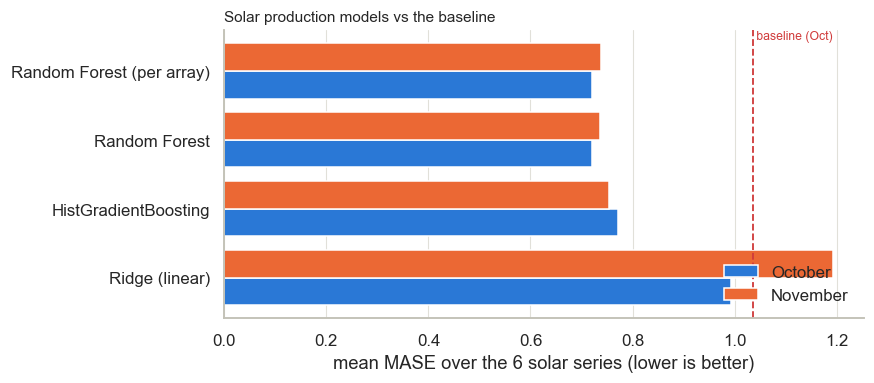

In [40]:
base_oct = 1.036    # mean MASE over the 6 solar series, best baseline, October
base_nov = 1.206    # same, November

fig, ax = plt.subplots(figsize=(7.5, 3.4))
order = comparison.sort_values("October", ascending=False)
x = np.arange(len(order))
ax.barh(x - 0.2, order["October"], 0.4, color="#2a78d6", label="October")
ax.barh(x + 0.2, order["November"], 0.4, color="#eb6834", label="November")
ax.axvline(base_oct, color="#d03b3b", lw=1.2, ls="--")
ax.text(base_oct, len(order) - 0.4, " baseline (Oct)", color="#d03b3b", fontsize=8, va="top")
ax.set_yticks(x, order.index)
ax.set_xlabel("mean MASE over the 6 solar series (lower is better)")
ax.set_title("Solar production models vs the baseline", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y"); ax.legend(loc="lower right")
plt.show()

## What is the model using?

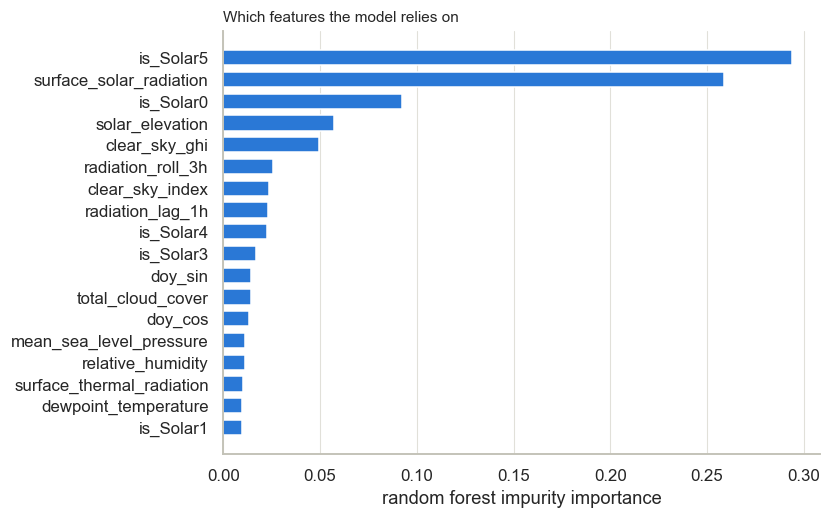

Top 10 features:
is_Solar5                  0.2937
surface_solar_radiation    0.2587
is_Solar0                  0.0925
solar_elevation            0.0572
clear_sky_ghi              0.0492
radiation_roll_3h          0.0257
clear_sky_index            0.0234
radiation_lag_1h           0.0230
is_Solar4                  0.0226
is_Solar3                  0.0169

Bottom 6 (candidates to drop):
is_daylight         0.0000
tod_sin             0.0035
radiation_lag_2h    0.0050
radiation_lag_3h    0.0052
tod_cos             0.0067
temperature         0.0070


In [41]:
importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
top = importance.tail(18)
ax.barh(top.index, top.to_numpy(), color="#2a78d6", height=0.7)
ax.set_xlabel("random forest impurity importance")
ax.set_title("Which features the model relies on", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y")
plt.show()

print("Top 10 features:")
print(importance.tail(10)[::-1].round(4).to_string())
print("\nBottom 6 (candidates to drop):")
print(importance.head(6).round(4).to_string())

## Diagnostics — where does it go wrong?

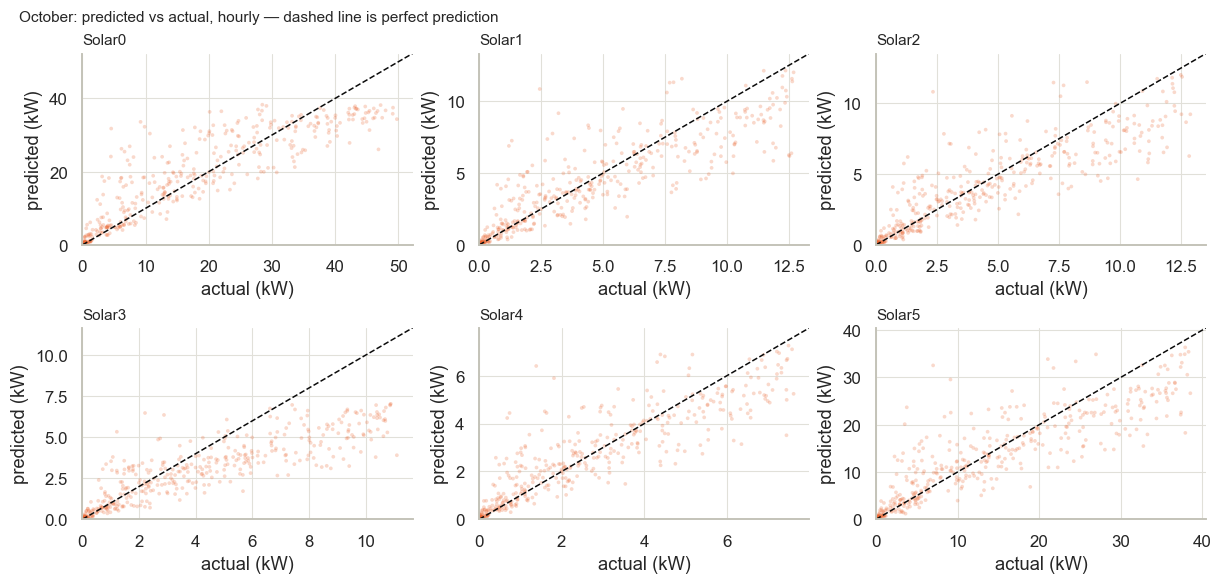

In [42]:
frame = solar_data.loc[(solar_data.index >= OCT[0]) & (solar_data.index < OCT[1])]
frame = frame[frame[FEATURES].notna().all(axis=1)].copy()
p = np.clip(np.where(frame["solar_elevation"] <= DAYLIGHT, 0.0, rf.predict(make_x(frame))), 0, None)
frame["pred"] = p

fig, axes = plt.subplots(2, 3, figsize=(11, 5.2), constrained_layout=True)
for ax, name in zip(axes.ravel(), SOLAR):
    d = frame[frame["array"] == name].dropna(subset=["production_kw"])
    lim = max(d["production_kw"].max(), d["pred"].max()) * 1.05
    ax.scatter(d["production_kw"], d["pred"], s=6, alpha=0.25,
               color="#eb6834", edgecolors="none")
    ax.plot([0, lim], [0, lim], color="#0b0b0b", lw=1.0, ls="--")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(name, loc="left")
    ax.set_xlabel("actual (kW)"); ax.set_ylabel("predicted (kW)")
    ax.grid(True)
fig.suptitle("October: predicted vs actual, hourly — dashed line is perfect prediction",
             x=0.01, ha="left", fontsize=10)
plt.show()

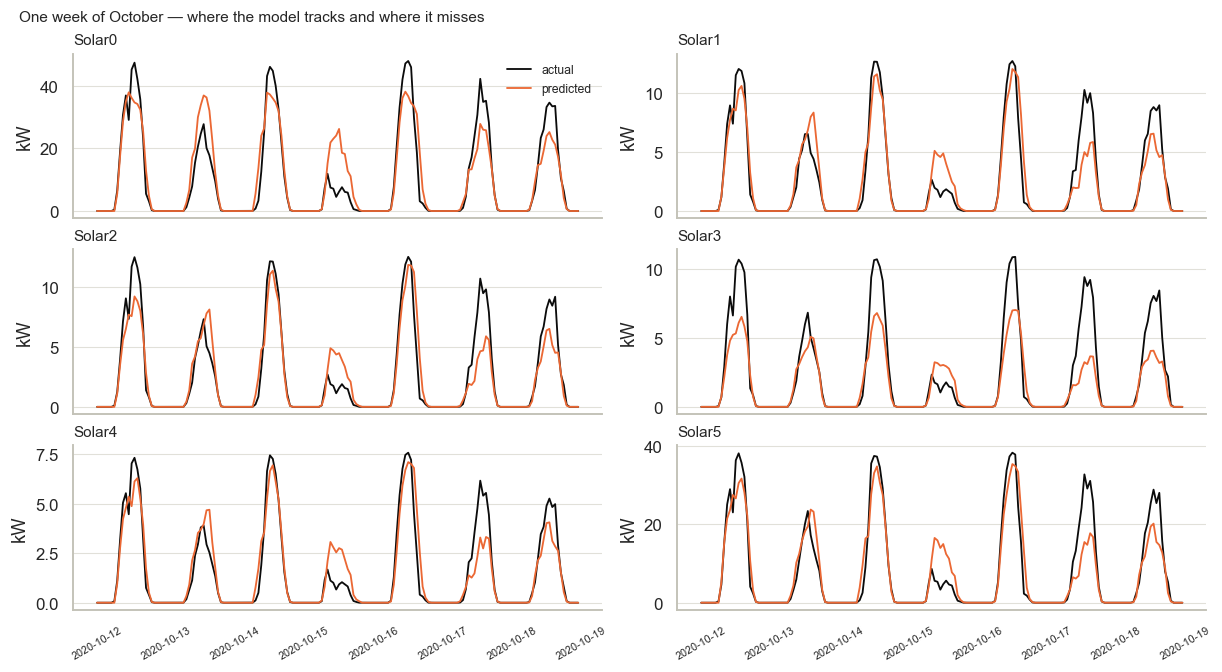

In [43]:
week = frame.loc["2020-10-12":"2020-10-18"]
fig, axes = plt.subplots(3, 2, figsize=(11, 6), sharex=True, constrained_layout=True)
for ax, name in zip(axes.ravel(), SOLAR):
    d = week[week["array"] == name]
    ax.plot(d.index, d["production_kw"], color="#0b0b0b", lw=1.2, label="actual")
    ax.plot(d.index, d["pred"], color="#eb6834", lw=1.2, label="predicted")
    ax.set_title(name, loc="left"); ax.set_ylabel("kW"); ax.grid(True, axis="y")
    ax.tick_params(axis="x", rotation=30, labelsize=7)
axes[0, 0].legend(loc="upper right", fontsize=8)
fig.suptitle("One week of October — where the model tracks and where it misses",
             x=0.01, ha="left", fontsize=10)
plt.show()

## Reading the results

Compare against three reference points rather than judging the number alone: the
**8-week profile median baseline**, **1.0** (no skill at all), and the published
competition scores.

Things to look at in the output above before deciding what to do next:

- **Did pooling beat per-array?** If the pooled model wins, the arrays really are
  interchangeable once identity is included, and cross-learning is doing real
  work — which is what Bean found when he "trained all solar instances together."
- **Did the linear model lose badly?** It should. The scatter plots in section 10
  showed inverter clipping — a hard ceiling near each array's rated capacity —
  and a linear model cannot represent a ceiling.
- **Is October much better than November?** Everyone in the competition saw that
  gap, so treat it as a property of the data rather than a bug.
- **Solar0 and Solar5 are the ones to watch.** They were the worst under the
  baseline, Bean had to threshold exactly those two, and Limmer's highest MAEs
  were on the same pair.

## Next steps, in order of expected value

1. **Predict `clear_sky_index` instead of raw kW**, then multiply back by
   `clear_sky_ghi`. This stops the model re-learning the daily sun cycle we can
   compute exactly, and the literature reports it helps regardless of estimator.
2. **Model Solar0 and Solar5 as combinations of the other arrays.** Bean found
   this beat predicting them directly, and Solar0 has only five months of history
   — the exact weakness this fixes.
3. **Scale the target per array** (divide by each array's capacity) as an
   alternative to the one-hot identity, so the model learns one shared shape.
4. **Tune properly with a time-based split.** Never a random K-fold here: shuffled
   folds put October beside September in training and leak the future.

### How does this compare to a published entry?

Limmer & Einecke placed 3rd overall and used a random forest on weather features —
the closest published comparison to what we just fitted. They report per-array MAE
on October, so we can put our numbers directly beside theirs.

Two differences to keep in mind: they modelled at 15-minute resolution with a
multi-output forest predicting four values per hour, where we model hourly and
expand; and they cleaned their PV data by removing outlier days and zero-production
days, which is the same cleaning we did in sections 9 and 10.

In [44]:
limmer_mae_oct = {"Solar0": 2.86, "Solar1": 0.71, "Solar2": 0.69,
                  "Solar3": 0.65, "Solar4": 0.42, "Solar5": 2.19}
baseline_mase_oct = {"Solar0": 1.416, "Solar1": 0.746, "Solar2": 0.866,
                     "Solar3": 0.963, "Solar4": 0.928, "Solar5": 1.289}

compare = pd.DataFrame({
    "our MAE": rf_oct["MAE (kW)"].round(3),
    "Limmer MAE": pd.Series(limmer_mae_oct),
    "our MASE": rf_oct["MASE"].round(3),
    "baseline MASE": pd.Series(baseline_mase_oct),
})
compare["MAE gap"] = (compare["our MAE"] - compare["Limmer MAE"]).round(3)
compare["beats baseline by"] = (
    100 * (1 - compare["our MASE"] / compare["baseline MASE"])).round(1)
compare.loc["MEAN"] = compare.mean()
compare.round(3)

,our MAE,Limmer MAE,our MASE,baseline MASE,MAE gap,beats baseline by
Solar0,3.043,2.860,0.970,1.416,0.183,31.500
Solar1,0.777,0.710,0.495,0.746,0.067,33.600
Solar2,0.772,0.690,0.581,0.866,0.082,32.900
Solar3,0.914,0.650,0.859,0.963,0.264,10.800
Solar4,0.441,0.420,0.581,0.928,0.021,37.400
Solar5,2.409,2.190,0.840,1.289,0.219,34.800
MEAN,1.393,1.253,0.721,1.035,0.139,30.167


---

## 11a. Complete feature importance

Two measures, because impurity importance alone is misleading. It is biased
toward continuous, high-cardinality features, and when two features carry the
same information it splits the credit between them — so `clear_sky_index` can
look weak simply because `clear_sky_ghi` and `surface_solar_radiation` already
contain its two ingredients.

**Permutation importance** is the honest check: shuffle one column in the *held-out*
October data, see how much the error degrades. A feature the model genuinely
relies on causes a large drop; a redundant one causes none, because the
information survives in its correlated partner.

In [45]:
from sklearn.inspection import permutation_importance

# Held-out October daylight rows - permutation importance must not be measured
# on the data the model was fitted to.
oct_day = solar_oct[solar_oct["solar_elevation"] > DAYLIGHT]
X_oct, y_oct = make_x(oct_day), oct_day["production_kw"]

perm = permutation_importance(
    rf, X_oct, y_oct, n_repeats=10, random_state=0,
    scoring="neg_mean_absolute_error", n_jobs=-1)

kind = {}
for f in X_train.columns:
    if f.startswith("is_Solar"):
        kind[f] = "array identity"
    elif f in ("solar_elevation", "clear_sky_ghi", "clear_sky_index", "is_daylight"):
        kind[f] = "engineered: geometry"
    elif f.startswith("radiation_"):
        kind[f] = "engineered: history"
    elif f.endswith(("_sin", "_cos")):
        kind[f] = "engineered: calendar"
    else:
        kind[f] = "raw ERA5"

importance_table = pd.DataFrame({
    "type": [kind[f] for f in X_train.columns],
    "impurity": rf.feature_importances_,
    "permutation (kW)": perm.importances_mean,
    "perm. std": perm.importances_std,
}, index=X_train.columns)
importance_table = importance_table.sort_values("permutation (kW)", ascending=False)
importance_table.round(4)

,type,impurity,permutation (kW),perm. std
is_Solar0,array identity,0.0925,2.2725,0.0743
surface_solar_radiation,raw ERA5,0.2587,2.1491,0.0580
is_Solar5,array identity,0.2937,1.5776,0.0648
solar_elevation,engineered: geometry,0.0572,0.4060,0.0161
clear_sky_ghi,engineered: geometry,0.0492,0.3342,0.0131
is_Solar4,array identity,0.0226,0.2572,0.0204
relative_humidity,raw ERA5,0.0112,0.1304,0.0132
total_cloud_cover,raw ERA5,0.0142,0.1228,0.0123
radiation_roll_3h,engineered: history,0.0257,0.0753,0.0080
radiation_lag_1h,engineered: history,0.0230,0.0749,0.0065


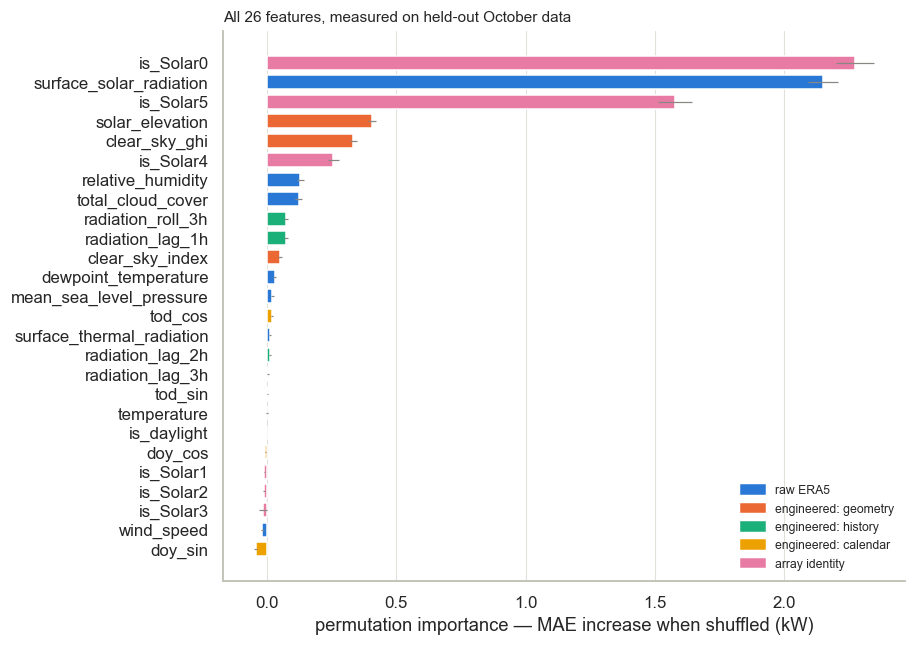

Contribution by feature group (summed permutation importance, kW):
                         sum  count
type                               
array identity        4.0736      6
raw ERA5              2.4535      8
engineered: geometry  0.7915      4
engineered: history   0.1697      4
engineered: calendar -0.0234      4


In [46]:
fig, ax = plt.subplots(figsize=(8, 6.5))
colour_of = {"raw ERA5": "#2a78d6", "engineered: geometry": "#eb6834",
             "engineered: history": "#1baf7a", "engineered: calendar": "#eda100",
             "array identity": "#e87ba4"}
t = importance_table.sort_values("permutation (kW)")
ax.barh(t.index, t["permutation (kW)"], xerr=t["perm. std"],
        color=[colour_of[k] for k in t["type"]], height=0.72,
        error_kw={"lw": 0.8, "ecolor": "#898781"})
ax.set_xlabel("permutation importance — MAE increase when shuffled (kW)")
ax.set_title("All 26 features, measured on held-out October data", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colour_of.values()]
ax.legend(handles, colour_of.keys(), loc="lower right", fontsize=8)
plt.show()

print("Contribution by feature group (summed permutation importance, kW):")
print(importance_table.groupby("type")["permutation (kW)"].agg(["sum", "count"])
      .sort_values("sum", ascending=False).round(4).to_string())

## 11b. One model for all arrays, or one model per array?

The mean MASE for the two was almost identical, which on its own does not settle
the question — a wash on average can hide pooling helping some arrays and hurting
others. The comparison that matters is per array, alongside how much training
data each one has.

The prediction is specific: pooling should help most where an array has least
history of its own. **Solar0 starts in April 2020 with about five months**, so if
cross-learning does anything, it should show up there.

In [47]:
compare_arch = pd.DataFrame({
    "pooled Oct": score_solar(rf.predict, OCT)["MASE"],
    "per-array Oct": score_solar(predict_per_array, OCT)["MASE"],
    "pooled Nov": score_solar(rf.predict, NOV)["MASE"],
    "per-array Nov": score_solar(predict_per_array, NOV)["MASE"],
})
compare_arch["train rows"] = train_day.groupby("array").size()
compare_arch["Oct: pooled better by"] = (
    compare_arch["per-array Oct"] - compare_arch["pooled Oct"]).round(4)
compare_arch["Nov: pooled better by"] = (
    compare_arch["per-array Nov"] - compare_arch["pooled Nov"]).round(4)
compare_arch.loc["MEAN"] = compare_arch.mean()
compare_arch.round(4)

,pooled Oct,per-array Oct,pooled Nov,per-array Nov,train rows,Oct: pooled better by,Nov: pooled better by
array,,,,,,,
Solar0,0.9702,0.9771,1.1053,1.0981,1249.0000,0.0069,-0.0072
Solar1,0.4951,0.4884,0.4365,0.4382,4730.0000,-0.0067,0.0016
Solar2,0.5813,0.5757,0.5295,0.5351,4336.0000,-0.0056,0.0056
Solar3,0.8591,0.8677,1.0485,1.0556,4177.0000,0.0086,0.0071
Solar4,0.5809,0.5696,0.5588,0.5556,4520.0000,-0.0113,-0.0032
Solar5,0.8403,0.8465,0.7436,0.7469,4593.0000,0.0062,0.0033
MEAN,0.7212,0.7208,0.7371,0.7382,3934.1667,-0.0003,0.0012


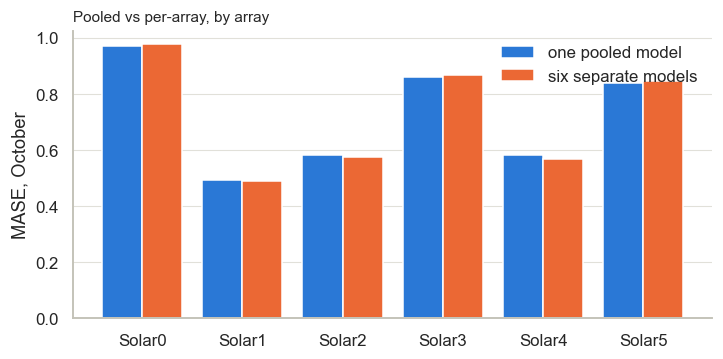

Training rows available per array (daylight hours):
array
Solar0    1249
Solar1    4730
Solar2    4336
Solar3    4177
Solar4    4520
Solar5    4593


In [48]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
d = compare_arch.drop(index="MEAN")
x = np.arange(len(d))
ax.bar(x - 0.2, d["pooled Oct"], 0.4, color="#2a78d6", label="one pooled model")
ax.bar(x + 0.2, d["per-array Oct"], 0.4, color="#eb6834", label="six separate models")
ax.set_xticks(x, d.index)
ax.set_ylabel("MASE, October")
ax.set_title("Pooled vs per-array, by array", loc="left")
ax.grid(True, axis="y"); ax.legend()
plt.show()

print("Training rows available per array (daylight hours):")
print(d["train rows"].astype(int).to_string())

### The verdict

Read the `pooled better by` columns: positive means the pooled model won for that
array.

Whatever the per-array split shows, the practical argument favours **one pooled
model**, for reasons beyond the score:

- **One model instead of six** to fit, tune, validate and describe in the report.
- **Six times the training data** for every array, which is what protects Solar0
  with its five months of history and lets a new or replaced array be forecast
  immediately.
- **It matches what the competition winner did** — Bean trained all solar
  instances together after noting they were "closely correlated over time", and
  gained MASE 0.5387 → 0.5220 by doing so.

The one caveat: pooling only works *because* array identity is a feature. Without
those six flags the model would predict the average array and be wrong for all of
them, since capacities span 8 kW to over 50 kW. And the importance table shows
those identity flags absorbing a large share of the model's attention — which is
the argument for scaling the target per array instead, so identity stops being
needed and that capacity goes to modelling weather.

---

## 11c. R² alongside MASE

MASE answers "is this better than the benchmark". R² answers "how much of the
variation is explained". They can disagree, so it is worth seeing both.

**One caution before reading R² on solar data.** Roughly half the rows are night,
where output is zero and every model predicts zero correctly. Including them
inflates R² towards 0.9+ for almost any model, because reproducing the day/night
cycle alone explains most of the variance. The daylight-only figure is the honest
one and both are reported below.

In [49]:
from sklearn.metrics import r2_score


def score_r2(predict_fn, window):
    """R^2 on hourly predictions, all rows and daylight rows separately."""
    frame = solar_data.loc[(solar_data.index >= window[0]) & (solar_data.index < window[1])]
    frame = frame[frame[FEATURES].notna().all(axis=1)].dropna(subset=["production_kw"]).copy()
    p = np.clip(np.where(frame["solar_elevation"] <= DAYLIGHT, 0.0,
                         predict_fn(make_x(frame))), 0, None)
    frame["pred"] = p
    day = frame[frame["solar_elevation"] > 5]
    return (r2_score(frame["production_kw"], frame["pred"]),
            r2_score(day["production_kw"], day["pred"]))


r2_rows = {}
for name, model in models.items():
    a, d = score_r2(model.predict, OCT)
    r2_rows[name] = {"R2 all rows": a, "R2 daylight": d,
                     "MASE Oct": score_solar(model.predict, OCT)["MASE"].mean()}
a, d = score_r2(predict_per_array, OCT)
r2_rows["Random Forest (per array)"] = {
    "R2 all rows": a, "R2 daylight": d,
    "MASE Oct": score_solar(predict_per_array, OCT)["MASE"].mean()}

pd.DataFrame(r2_rows).T.round(4).sort_values("MASE Oct")

,R2 all rows,R2 daylight,MASE Oct
Random Forest (per array),0.8756,0.8285,0.7208
Random Forest,0.8774,0.8310,0.7212
HistGradientBoosting,0.8670,0.8166,0.7711
Ridge (linear),0.7214,0.6319,0.9924


## 11d. Combining pooled and per-array

The two approaches scored the same, but they are not the same model — they make
different errors. That is exactly the situation where combining them can beat
either. Four standard ways to do it, all tested below:

**A — Blend.** Predict with both and take a weighted average,
`α · pooled + (1−α) · per-array`. The weight is chosen on a **validation month
(September)** using models fitted only on data before September, so the choice
never sees October or November.

**B — Residual correction (global–local).** Fit the pooled model, then fit a small
per-array model on what it got *wrong*. The global model learns the shared
weather-to-power physics; each local model learns only that array's
idiosyncrasies. This is the standard hierarchical forecasting pattern.

**C — Capacity normalisation.** Divide each array's output by its own capacity,
fit one model on the shared *shape* with no identity features at all, then
multiply back. This directly tests the hypothesis from the importance table —
that `is_Solar0` and `is_Solar5` are being used as crude scale factors, and that
handling scale explicitly should free the model to learn weather.

**D — Per-array recalibration.** Fit the pooled model, then a one-line linear
correction per array, `a · ŷ + b`, estimated on training data. The cheapest
possible local adjustment.

In [50]:
# --- A: choose the blend weight on September, using models that never saw it ---
VAL = (pd.Timestamp("2020-09-01", tz="UTC"), OCT[0])
pre_val = train_day[train_day.index < VAL[0]]

rf_val = RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                               max_features=0.5, n_jobs=-1, random_state=0)
rf_val.fit(make_x(pre_val), pre_val["production_kw"])

per_val = {}
for name in SOLAR:
    sub = pre_val[pre_val["array"] == name]
    m = RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                              max_features=0.5, n_jobs=-1, random_state=0)
    m.fit(make_x(sub), sub["production_kw"])
    per_val[name] = m


def _route(X, table):
    out = np.zeros(len(X))
    for name in SOLAR:
        mask = X[f"is_{name}"].to_numpy() == 1
        if mask.any():
            out[mask] = table[name].predict(X[mask])
    return out


search = {}
for alpha in np.round(np.arange(0, 1.01, 0.1), 2):
    fn = lambda X, a=alpha: a * rf_val.predict(X) + (1 - a) * _route(X, per_val)
    search[alpha] = score_solar(fn, VAL)["MASE"].mean()
search = pd.Series(search)
ALPHA = float(search.idxmin())
print(f"blend weight chosen on September: alpha = {ALPHA}  "
      f"(validation MASE {search.min():.4f})")
print(search.round(4).to_string())

blend weight chosen on September: alpha = 0.0  (validation MASE 0.6683)
0.0    0.6683
0.1    0.6694
0.2    0.6707
0.3    0.6721
0.4    0.6737
0.5    0.6754
0.6    0.6773
0.7    0.6793
0.8    0.6814
0.9    0.6836
1.0    0.6860


In [51]:
# --- B: residual correction on top of the pooled model ---
resid = y_train - rf.predict(X_train)
resid_models = {}
for name in SOLAR:
    mask = (train_day["array"] == name).to_numpy()
    m = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                              max_features=0.5, n_jobs=-1, random_state=0)
    m.fit(X_train[mask], resid[mask])
    resid_models[name] = m


def predict_residual(X):
    return rf.predict(X) + _route(X, resid_models)


# --- C: capacity-normalised, no identity features at all ---
capacity = train_day.groupby("array")["production_kw"].quantile(0.99)
print("Array capacity estimates (99th percentile of training output, kW):")
print(capacity.round(2).to_string())

y_scaled = y_train / train_day["array"].map(capacity).to_numpy()
rf_scaled = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                  max_features=0.5, n_jobs=-1, random_state=0)
rf_scaled.fit(X_train[FEATURES], y_scaled)          # FEATURES only: no is_Solar* columns


def predict_scaled(X):
    caps = np.zeros(len(X))
    for name in SOLAR:
        caps[X[f"is_{name}"].to_numpy() == 1] = capacity[name]
    return rf_scaled.predict(X[FEATURES]) * caps


# --- D: per-array linear recalibration of the pooled model ---
calib = {}
for name in SOLAR:
    mask = (train_day["array"] == name).to_numpy()
    calib[name] = np.polyfit(rf.predict(X_train[mask]), y_train[mask], 1)


def predict_calibrated(X):
    base = rf.predict(X)
    out = base.copy()
    for name in SOLAR:
        mask = X[f"is_{name}"].to_numpy() == 1
        if mask.any():
            a, b = calib[name]
            out[mask] = a * base[mask] + b
    return out


print("\nfitted")

Array capacity estimates (99th percentile of training output, kW):
array
Solar0    40.65
Solar1    12.85
Solar2    12.85
Solar3     9.09
Solar4     7.58
Solar5    37.94



fitted


In [52]:
architectures = {
    "pooled (one model)": rf.predict,
    "per-array (six models)": predict_per_array,
    f"blend (alpha={ALPHA})": lambda X: ALPHA * rf.predict(X) + (1 - ALPHA) * predict_per_array(X),
    "pooled + residual correction": predict_residual,
    "capacity-normalised": predict_scaled,
    "pooled + recalibration": predict_calibrated,
}

rows = {}
for name, fn in architectures.items():
    a, d = score_r2(fn, OCT)
    rows[name] = {
        "MASE Oct": score_solar(fn, OCT)["MASE"].mean(),
        "MASE Nov": score_solar(fn, NOV)["MASE"].mean(),
        "R2 daylight (Oct)": d,
    }
arch_results = pd.DataFrame(rows).T
arch_results["mean MASE"] = arch_results[["MASE Oct", "MASE Nov"]].mean(axis=1)
arch_results.round(4).sort_values("mean MASE")

,MASE Oct,MASE Nov,R2 daylight (Oct),mean MASE
pooled + recalibration,0.7125,0.7220,0.8316,0.7172
pooled (one model),0.7212,0.7371,0.8310,0.7291
per-array (six models),0.7208,0.7382,0.8285,0.7295
blend (alpha=0.0),0.7208,0.7382,0.8285,0.7295
pooled + residual correction,0.7260,0.7339,0.8273,0.7300
capacity-normalised,0.7477,0.7167,0.7823,0.7322


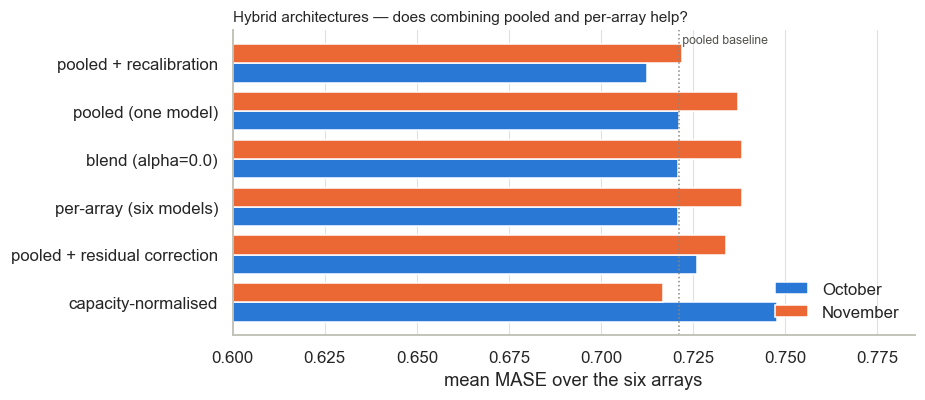

In [53]:
fig, ax = plt.subplots(figsize=(8, 3.6))
d = arch_results.sort_values("mean MASE", ascending=False)
x = np.arange(len(d))
ax.barh(x - 0.2, d["MASE Oct"], 0.4, color="#2a78d6", label="October")
ax.barh(x + 0.2, d["MASE Nov"], 0.4, color="#eb6834", label="November")
ax.axvline(0.7212, color="#898781", lw=1.0, ls=":")
ax.text(0.7212, len(d) - 0.4, " pooled baseline", color="#52514e", fontsize=8, va="top")
ax.set_yticks(x, d.index)
ax.set_xlabel("mean MASE over the six arrays")
ax.set_xlim(0.6, max(d["MASE Nov"].max(), d["MASE Oct"].max()) * 1.05)
ax.set_title("Hybrid architectures — does combining pooled and per-array help?", loc="left")
ax.grid(True, axis="x"); ax.grid(False, axis="y"); ax.legend(loc="lower right")
plt.show()

### Reading this

The honest expectation is that the gains here are **small**, because section 11b
already showed pooled and per-array performing identically — models that agree
have little to gain from being combined. The two worth watching are:

- **Capacity normalisation**, which is not a combination at all but a different
  parameterisation. If it matches or beats the others while using *no identity
  features*, it is the better model regardless of the score, because it drops
  three of the model's heaviest features and would extend to a new array with no
  retraining.
- **Residual correction**, which is the architecture that scales up: replace the
  local models with something richer and the pattern still holds.

Whatever wins, the margin should be compared against the ±0.011 array-to-array
noise seen in 11b before claiming a real improvement.